# Etap 1

### **Określenie problemu oraz kontekstu**

**Kontekst:**
Zbiór danych Titanic to klasyczny zestaw danych wykorzystywany w projektach uczenia maszynowego. Zawiera on informacje o pasażerach słynnego statku RMS Titanic, który zatonął w 1912 roku. Celem analizy jest przewidzenie, którzy pasażerowie przeżyli katastrofę na podstawie dostępnych informacji, takich jak wiek, płeć, klasa podróży czy port zaokrętowania. Dane zawierają zarówno cechy numeryczne (np. wiek, liczba rodzeństwa), jak i kategoryczne (np. płeć, klasa).

**Problem:**
Celem projektu jest rozwiązanie problemu **klasyfikacji binarnej**:

> **Czy dany pasażer przeżył katastrofę Titanica?**

Zmienne wejściowe to cechy pasażerów (`age`, `sex`, `pclass`, `fare`, `sibsp`, `parch`, `embarked` itd.), natomiast zmienną docelową jest `survived`, która przyjmuje wartość:

* `1` – pasażer przeżył,
* `0` – pasażer zginął.

**Wyzwania:**
Zbiór zawiera braki danych, np. w kolumnie `age`, a także kolumny niosące mało informacji lub duplikujące się znaczeniowo (np. `alive`, `who`, `class`). Konieczne jest ich oczyszczenie i przygotowanie do pracy z modelami uczenia maszynowego. Kolejnym wyzwaniem jest odpowiednie zakodowanie danych kategorycznych i przeskalowanie cech liczbowych.

In [ ]:
# importy

# Biblioteki zewnętrzne
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Imbalanced-learn
from imblearn.combine import SMOTEENN

# scikit-learn - dane
from sklearn.datasets import make_classification, make_swiss_roll

# scikit-learn - model selection
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    StratifiedKFold, RandomizedSearchCV
)

# scikit-learn - preprocessing i pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# scikit-learn - klasyfikatory
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier,
    VotingClassifier, StackingClassifier, HistGradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

# scikit-learn - metryki
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc, make_scorer
)

# scikit-learn - analiza cech
from sklearn.inspection import permutation_importance

# scikit-learn - redukcja wymiarów
from sklearn.decomposition import PCA

# scikit-learn - inne
from sklearn import tree


In [ ]:
# Wczytanie danych
df = sns.load_dataset("titanic")

In [ ]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["sex"].value_counts())
print(df["pclass"].value_counts())
print(df["embarked"].value_counts())
print(df["embark_town"].value_counts())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

# Podstawowa analiza zbioru danych – Titanic

1. Liczba próbek i cech:
Zbiór zawiera 891 obserwacji (pasażerów) i 15 kolumn (cech). Dane opisują różne atrybuty pasażerów, takie jak wiek, płeć, klasa, cena biletu, liczba członków rodziny na pokładzie itd.

2. Typy danych:
Zmienna docelowa (survived) to zmienna binarna typu całkowitego (int64), przyjmująca wartości 0 lub 1. Inne kolumny to:

liczby całkowite (int64) – pclass, sibsp, parch,

liczby zmiennoprzecinkowe (float64) – age, fare,

kategorie tekstowe (object / category) – sex, embarked, class, who, embark_town, alive, deck,

wartości logiczne (bool) – adult_male, alone.

3. Braki danych:
W zbiorze występują znaczące braki danych:

age – 177 braków (ok. 20%),

deck – aż 688 braków (ponad 77%), co sugeruje, że ta cecha może być nieprzydatna,

embarked i embark_town – po 2 braki (nieistotna liczba, można uzupełnić trywialnie).

4. Duplikaty:
Znaleziono 107 zduplikowanych wierszy, co jest istotne i należy je usunąć w fazie czyszczenia danych.

5. Statystyki opisowe:

Średni wiek pasażera: ok. 29,7 lat, z zakresem od 0,42 do 80 lat,

Ceny biletów (fare) mają duży rozrzut (0 – 512), warto będzie je przeskalować,

Najczęstsze liczby rodzeństwa i dzieci na pokładzie to 0 lub 1, co może wpływać na przeżywalność.

6. Uwagi dotyczące kolumn:

Kolumny class i pclass oznaczają to samo (klasę podróży), ale są w różnych formatach – jedna kategoryczna (First, Second, Third), druga liczbowa (1–3). W projekcie warto zostawić tylko jedną.

Kolumny alive i survived również przekazują tę samą informację – warto zostawić tylko survived jako numeryczną zmienną docelową.

who, adult_male, alone to zmienne pochodne, można je albo pominąć, albo wykorzystać w analizie zależności (np. korelacji).

549 pasażerów nie przeżyło (ok. 61,6%),

342 pasażerów przeżyło (ok. 38,4%).

Zbiór jest niezrównoważony, co należy wziąć pod uwagę przy budowie modelu predykcyjnego.

sex: 577 mężczyzn, 314 kobiet,

pclass: najwięcej pasażerów w 3. klasie,

embarked: większość wsiadła w Southampton (S), mniej w Cherbourgu (C) i Queenstown (Q).


Mimo że korelacje są raczej słabe, można zauważyć:

umiarkowaną korelację między fare i pclass (im wyższa klasa, tym wyższa cena),

delikatny związek age i parch/sibsp (więcej dzieci = młodszy wiek),

zmienna survived nie ma silnych korelacji liniowych z żadną zmienną liczbową, ale związki nieliniowe mogą być istotne.

age ma rozkład zbliżony do normalnego z lekkim przesunięciem w lewo i kilkoma pikami (np. dzieci),

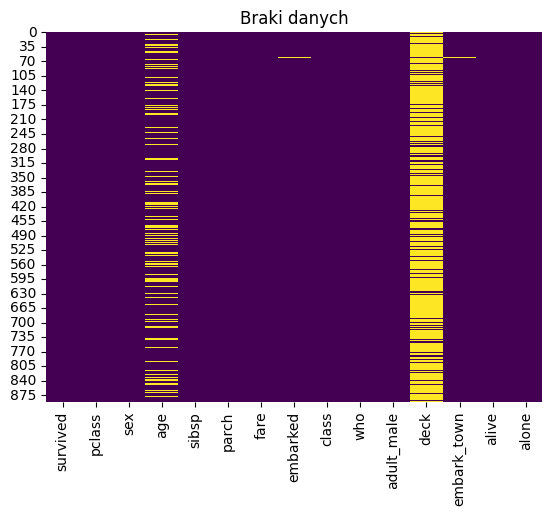

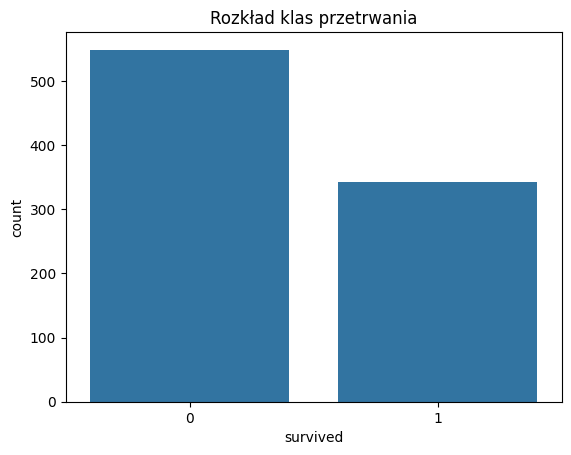

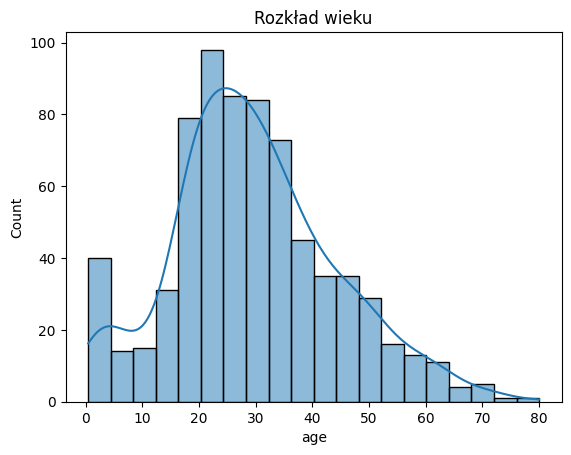

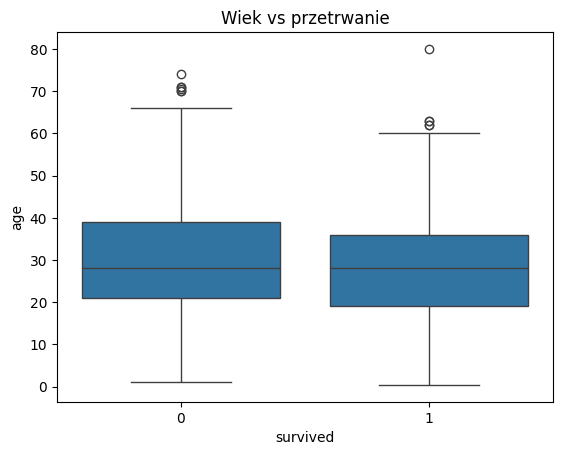

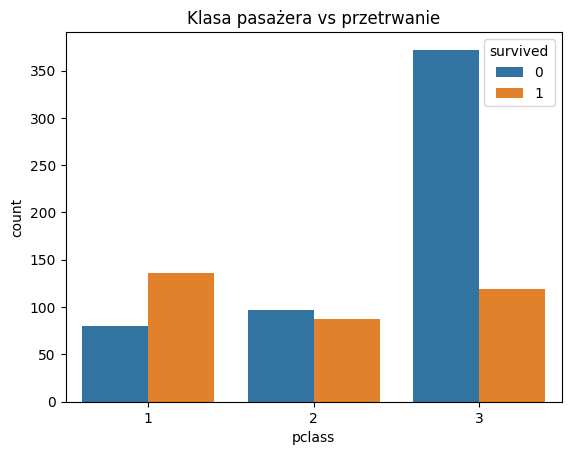

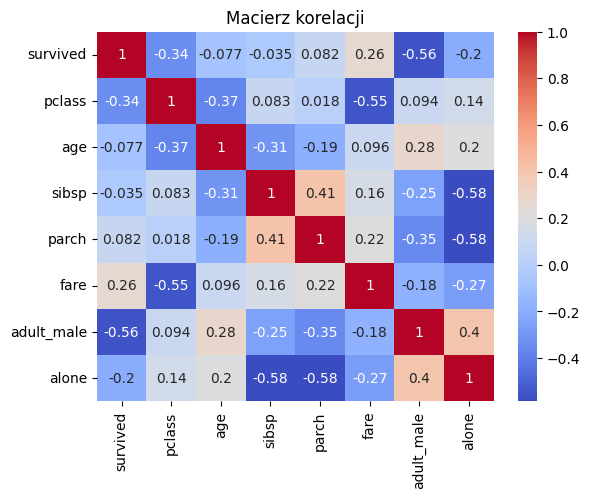

survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [ ]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Braki danych")
plt.show()

sns.countplot(data=df, x='survived')
plt.title("Rozkład klas przetrwania")
plt.show()

sns.histplot(data=df, x='age', kde=True)
plt.title("Rozkład wieku")
plt.show()

sns.boxplot(data=df, x='survived', y='age')
plt.title("Wiek vs przetrwanie")
plt.show()

sns.countplot(data=df, x='pclass', hue='survived')
plt.title("Klasa pasażera vs przetrwanie")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Macierz korelacji")
plt.show()

print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True))

**1. Braki danych – mapa cieplna (`sns.heatmap(df.isnull())`)**

Ta wizualizacja pokazuje, które kolumny zawierają braki danych. Najbardziej rzuca się w oczy kolumna `deck`, która zawiera bardzo dużo braków (ok. 77%). Mniejsze braki występują w `age`, `embarked` i `embark_town`. Warto się zastanowić, czy kolumnę `deck` w ogóle zachować (mało danych), a pozostałe uzupełnić lub usunąć wiersze z brakami.

---

**2. Rozkład klas przetrwania (`sns.countplot(x='survived')`)**

Wizualizacja potwierdza wcześniejsze obserwacje: liczba pasażerów, którzy nie przeżyli (klasa 0), jest znacznie większa niż tych, którzy przeżyli (klasa 1). Zbiór danych jest więc **niezrównoważony**, co może wpływać na skuteczność klasyfikatorów – warto będzie rozważyć metody balansowania klas (np. oversampling lub weighted loss).

---

**3. Rozkład wieku (`sns.histplot(x='age')`)**

Rozkład wieku ma kształt zbliżony do normalnego, ale z wyraźnym pikiem dla dzieci i nieco większą koncentracją wartości w przedziale 20–40 lat. To istotna zmienna – później można sprawdzić, czy wiek wpływa na przeżycie.

---

**4. Wiek a przetrwanie (`sns.boxplot(x='survived', y='age')`)**

Boxplot pokazuje, że pasażerowie, którzy przeżyli (klasa 1), byli średnio młodsi niż ci, którzy nie przeżyli. Widać też więcej dzieci w grupie osób, które przeżyły. Może to wskazywać, że dzieci miały większe szanse przeżycia (np. „kobiety i dzieci najpierw”).

---

**5. Klasa pasażera a przetrwanie (`sns.countplot(x='pclass', hue='survived')`)**

Zdecydowanie najwięcej ofiar było w 3. klasie. W 1. klasie przeżyło znacznie więcej pasażerów niż zginęło, a w 3. klasie odwrotnie. Klasa podróży jest więc **silnym predyktorem przeżycia**, zapewne przez lepszy dostęp do szalup lub załogi.

---

**6. Macierz korelacji (`sns.heatmap(df.corr(numeric_only=True))`)**

Macierz potwierdza, że:

* `fare` i `pclass` są ze sobą silnie skorelowane (negatywnie),
* zmienna `survived` nie koreluje mocno z żadną pojedynczą zmienną liczbową, ale `fare`, `parch`, `sibsp` i `age` mogą mieć wpływ, zwłaszcza nieliniowy lub po interakcji.

---

**7. Rozkład wartości zmiennej `survived`:**

```
0    549
1    342
Name: survived, dtype: int64

0    0.616162
1    0.383838
Name: survived, dtype: float64
```

Ostateczne potwierdzenie, że mamy **ok. 62% ofiar i 38% ocalałych**.

In [ ]:
# Usunięcie wybranch kolumn
df.drop(['deck', 'embark_town', 'alive', 'who', 'adult_male'], axis=1, inplace=True)
#deck – bardzo dużo braków (ponad 75%), więc słusznie usunięta.
#embark_town, alive, who, adult_male – to kolumny skorelowane z innymi zmiennymi (embarked, survived, sex) lub zbyt ogólne / pochodne. Ich usunięcie jest uzasadnione, by uniknąć redundancji.

# Uzupełnienie braków
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Usunięcie duplikatów
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

Ten fragment kodu przygotowuje dane z DataFrame `df` do dalszej analizy lub modelowania. Na początku usuwa kolumny, które są mało użyteczne lub nadmiarowe, następnie uzupełnia brakujące wartości, a na końcu usuwa ewentualne duplikaty i resetuje indeksy.

Najpierw usuwane są kolumny:

* `deck`, ponieważ zawiera zbyt wiele brakujących danych (ponad 75%).
* `embark_town`, `alive`, `who`, `adult_male`, które są mocno skorelowane z innymi zmiennymi (np. `embarked`, `survived`, `sex`) lub są ich pochodnymi, przez co ich obecność wprowadza redundancję.

Następnie uzupełniane są brakujące wartości:

* W kolumnie `age` wstawiana jest wartość mediany wieku.
* W kolumnie `embarked` – najczęściej występująca wartość (moda).

Na koniec usuwane są zduplikowane wiersze i resetowany jest indeks, aby numeracja wierszy była spójna po czyszczeniu danych. Wszystkie te operacje poprawiają jakość danych i zapobiegają problemom w dalszej analizie lub trenowaniu modeli.


In [ ]:
#Kodowanie zmiennych kategorycznych (One-Hot Encoding):
df = pd.get_dummies(df, columns=['sex', 'embarked', 'class'], drop_first=True)

Ten fragment kodu odpowiada za zakodowanie zmiennych kategorycznych przy użyciu metody One-Hot Encoding. Operacja ta przekształca wybrane kolumny zawierające dane kategoryczne (sex, embarked, class) w zestaw nowych kolumn binarnych (0/1), reprezentujących obecność danej kategorii w każdym wierszu.

Argument drop_first=True sprawia, że z każdej grupy kategorii pomijana jest pierwsza (referencyjna), co zapobiega problemowi wielokolinearności w modelach liniowych (czyli sytuacji, w której kolumny są liniowo zależne).

In [ ]:
#Skalowanie danych
scaler = StandardScaler()
features = df.drop('survived', axis=1)
target = df['survived']
scaled_features = scaler.fit_transform(features)
features_scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
print(features_scaled_df.dtypes)

pclass          float64
age             float64
sibsp           float64
parch           float64
fare            float64
alone           float64
sex_male        float64
embarked_Q      float64
embarked_S      float64
class_Second    float64
class_Third     float64
dtype: object


Ten fragment kodu odpowiada za skalowanie cech numerycznych w zbiorze danych przy użyciu standaryzacji (`StandardScaler`). Celem skalowania jest przekształcenie zmiennych tak, aby miały średnią 0 i odchylenie standardowe 1. Jest to szczególnie ważne dla wielu algorytmów uczenia maszynowego, które są wrażliwe na różnice w skali cech (np SVM, KNN).

Najpierw oddzielane są cechy (`features`) od zmiennej docelowej (`target`, czyli `survived`). Następnie `StandardScaler` dopasowuje się do danych (`fit_transform`) i przekształca je. Wynikowe dane są przekształcane do DataFrame (`features_scaled_df`) z zachowaniem oryginalnych nazw kolumn, co ułatwia dalszą analizę. Na końcu wypisywane są typy danych poszczególnych kolumn, by upewnić się, że wszystkie zmienne są typu numerycznego.


In [ ]:
#Podział zboioru na na uczący i testowy
X_train, X_test, y_train, y_test = train_test_split(features_scaled_df, target, stratify=target, test_size=0.2, random_state=42)

# Etap 2:

## Przeprowadzenie uczenia modelu:

Ten fragment kodu realizuje kompletny proces trenowania i porównywania wielu klasyfikatorów uczenia maszynowego na przetworzonym zbiorze danych. Składa się z 3 głównych części:

**1. Definicja modeli** – Tworzony jest słownik `models`, zawierający różne klasyfikatory, m.in. regresję logistyczną, las losowy, SVC, sieci neuronowe (MLP), boosting (GradientBoosting, AdaBoost, HistGradientBoosting), a także drzewa decyzyjne, k-najbliższych sąsiadów, czy klasyfikator SGD. Większość modeli ma ustawiony `random_state=42` dla powtarzalności wyników i włączoną wagę klas (tam, gdzie to sensowne), by uwzględnić ewentualną nierównowagę klas.

**2. Funkcje pomocnicze**:

* `evaluate_model(name, model)` – funkcja trenuje model na zbiorze treningowym, ocenia go za pomocą walidacji krzyżowej (3-krotnej) i drukuje metryki: dokładność (accuracy), precyzję, czułość (recall), F1-score i pełny raport klasyfikacji. Generuje również macierz pomyłek oraz wykresy Precision-Recall vs. Threshold i krzywą ROC (o ile model wspiera `predict_proba` lub `decision_function`).
* `test_evaluation(model, name)` – funkcja testuje model na zbiorze testowym i drukuje najważniejsze metryki oraz macierz pomyłek.

**3. Trening i ocena modeli**:

* Każdy z modeli jest trenowany i oceniany przy użyciu funkcji `evaluate_model`, a wytrenowane modele są przechowywane w słowniku `trained_models`.
* Następnie każdy z tych modeli oceniany jest na zbiorze testowym przy pomocy `test_evaluation`, by porównać jakość ich predykcji poza treningiem.


SGDClassifier:
Accuracy (CV): 0.7047433672591966
Precision: 0.627177700348432
Recall: 0.703125
F1 Score: 0.6629834254143646
              precision    recall  f1-score   support

           0       0.77      0.71      0.74       364
           1       0.63      0.70      0.66       256

    accuracy                           0.70       620
   macro avg       0.70      0.70      0.70       620
weighted avg       0.71      0.70      0.71       620



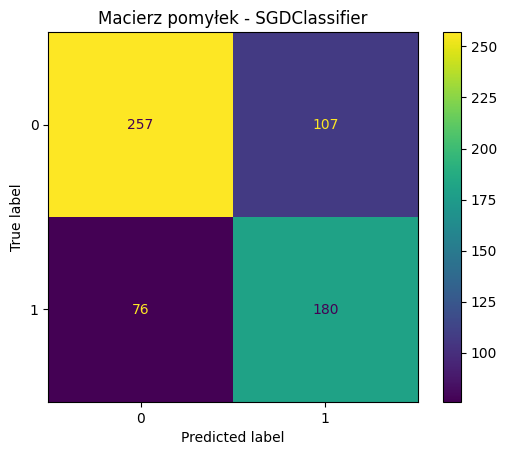

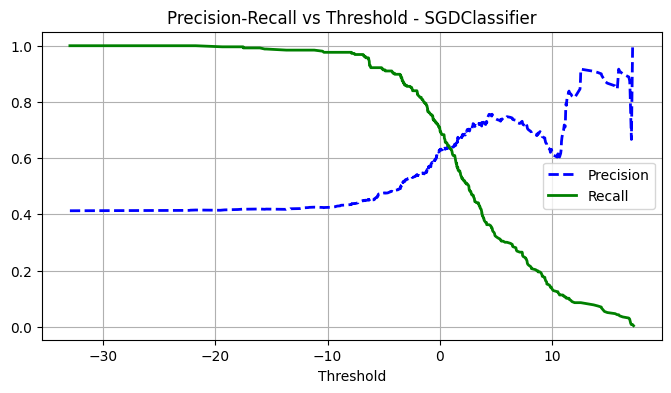

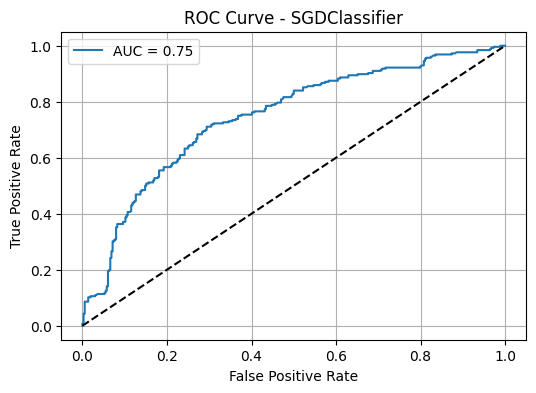


RandomForestClassifier:
Accuracy (CV): 0.7774416459515657
Precision: 0.7657657657657657
Recall: 0.6640625
F1 Score: 0.7112970711297071
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       364
           1       0.77      0.66      0.71       256

    accuracy                           0.78       620
   macro avg       0.77      0.76      0.77       620
weighted avg       0.78      0.78      0.77       620



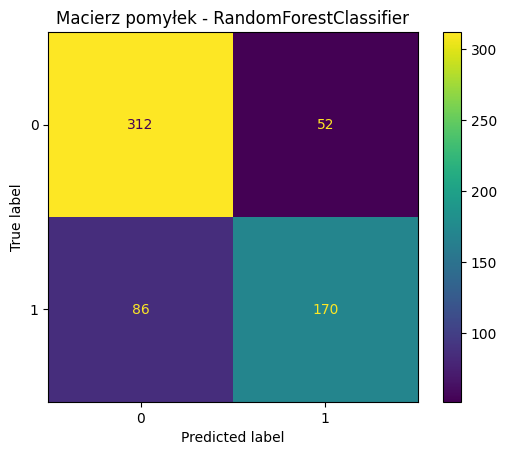

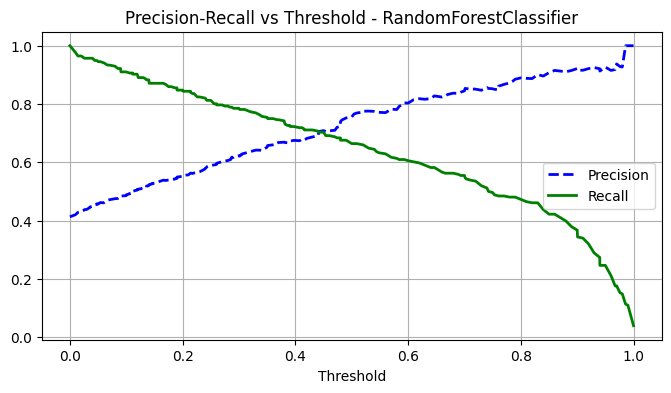

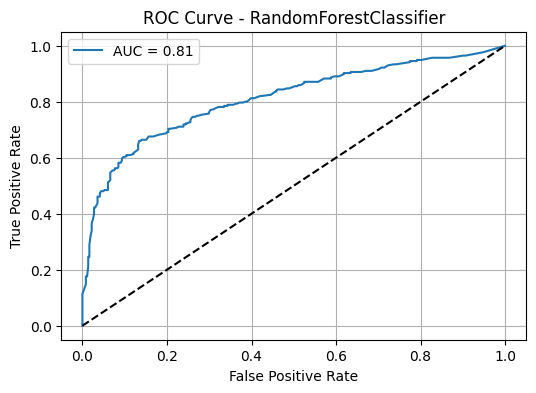


KNeighborsClassifier:
Accuracy (CV): 0.7726498131732408
Precision: 0.7555555555555555
Recall: 0.6640625
F1 Score: 0.7068607068607069
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       364
           1       0.76      0.66      0.71       256

    accuracy                           0.77       620
   macro avg       0.77      0.76      0.76       620
weighted avg       0.77      0.77      0.77       620



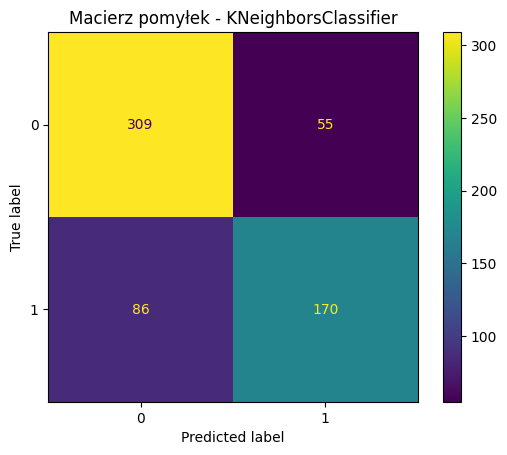

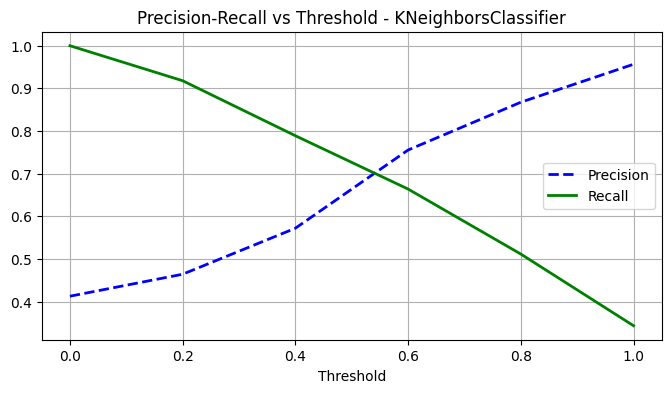

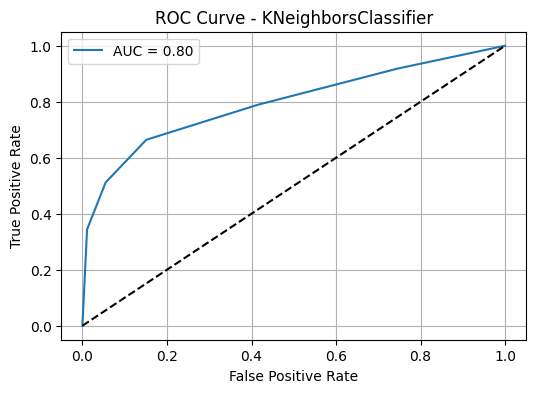


LogisticRegression:
Accuracy (CV): 0.7613307693510311
Precision: 0.7014925373134329
Recall: 0.734375
F1 Score: 0.7175572519083969
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       364
           1       0.70      0.73      0.72       256

    accuracy                           0.76       620
   macro avg       0.75      0.76      0.76       620
weighted avg       0.76      0.76      0.76       620



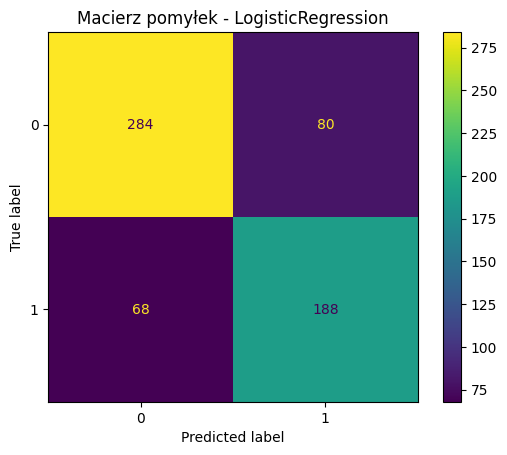

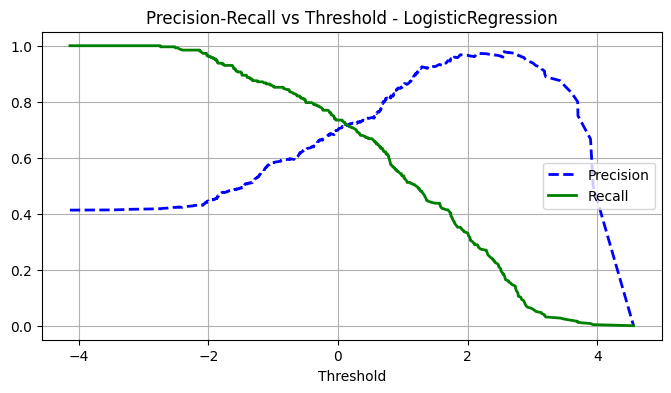

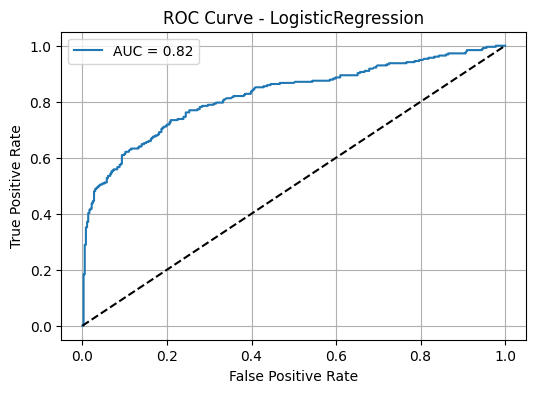


SVC RBF:
Accuracy (CV): 0.7742366680737301
Precision: 0.7521739130434782
Recall: 0.67578125
F1 Score: 0.7119341563786008
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       364
           1       0.75      0.68      0.71       256

    accuracy                           0.77       620
   macro avg       0.77      0.76      0.76       620
weighted avg       0.77      0.77      0.77       620



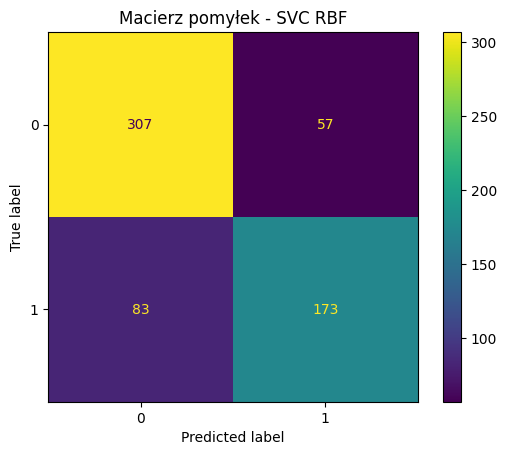

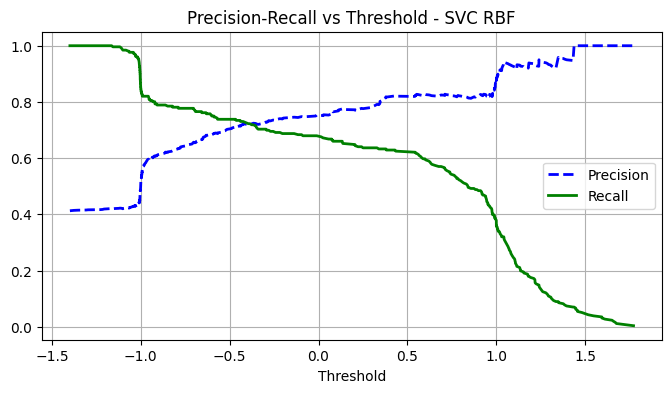

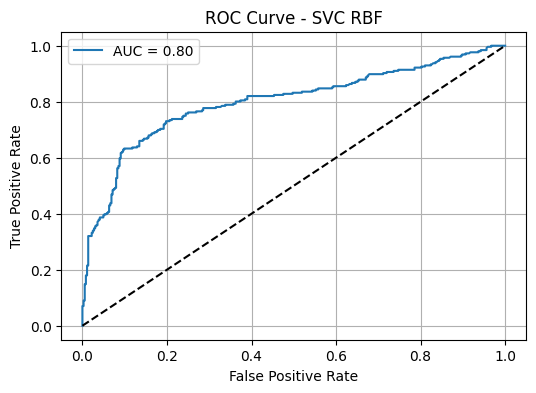


GradientBoostingClassifier:
Accuracy (CV): 0.7935837906289573
Precision: 0.8047619047619048
Recall: 0.66015625
F1 Score: 0.7253218884120172
              precision    recall  f1-score   support

           0       0.79      0.89      0.83       364
           1       0.80      0.66      0.73       256

    accuracy                           0.79       620
   macro avg       0.80      0.77      0.78       620
weighted avg       0.79      0.79      0.79       620



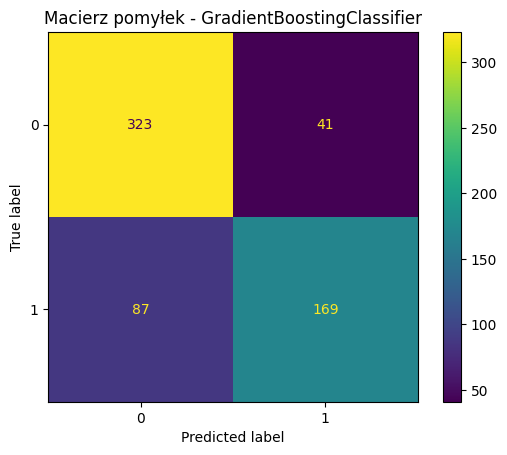

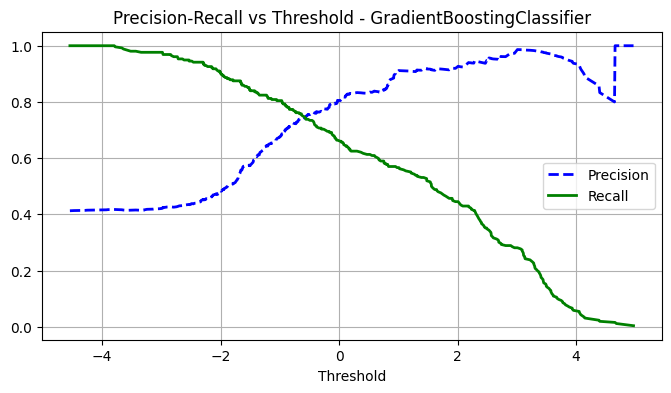

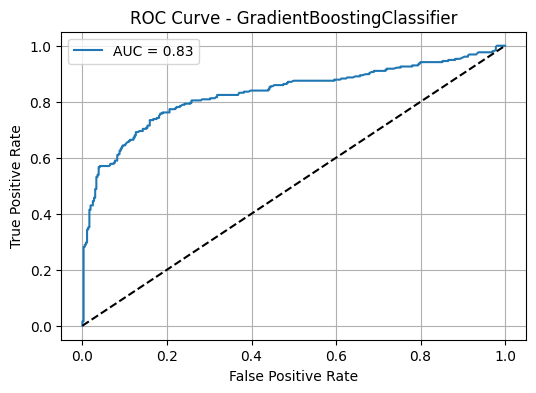


AdaBoostClassifier:
Accuracy (CV): 0.7726029110579554
Precision: 0.7309236947791165
Recall: 0.7109375
F1 Score: 0.7207920792079208
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       364
           1       0.73      0.71      0.72       256

    accuracy                           0.77       620
   macro avg       0.77      0.76      0.76       620
weighted avg       0.77      0.77      0.77       620



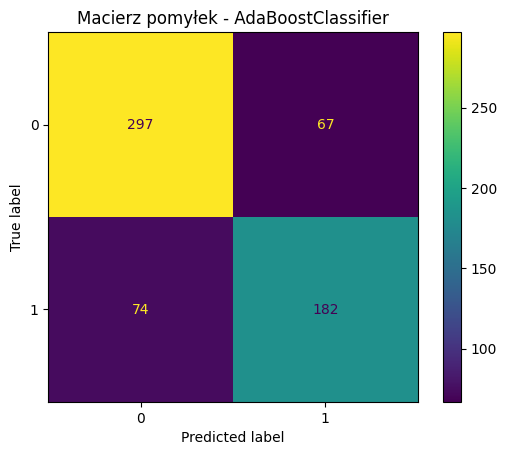

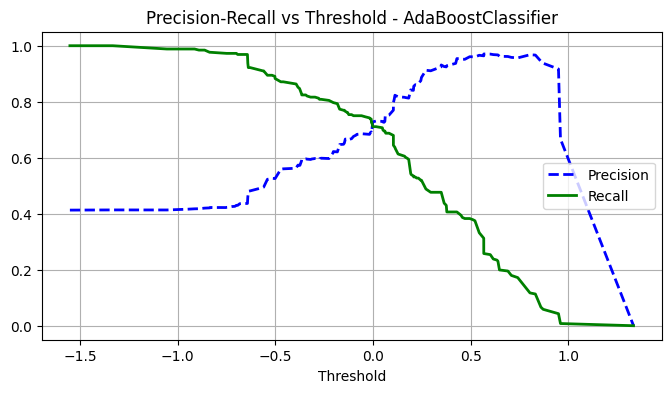

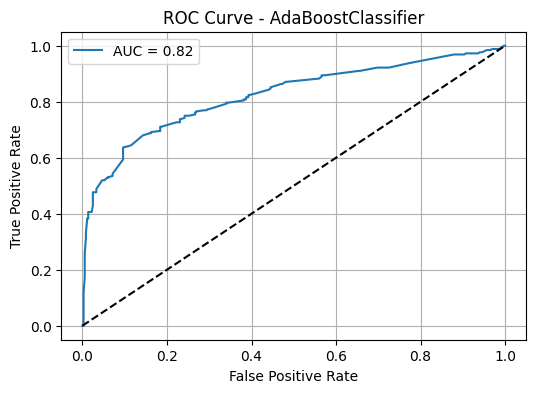


DecisionTree:
Accuracy (CV): 0.7209871331863734
Precision: 0.6590038314176245
Recall: 0.671875
F1 Score: 0.6653771760154739
              precision    recall  f1-score   support

           0       0.77      0.76      0.76       364
           1       0.66      0.67      0.67       256

    accuracy                           0.72       620
   macro avg       0.71      0.71      0.71       620
weighted avg       0.72      0.72      0.72       620



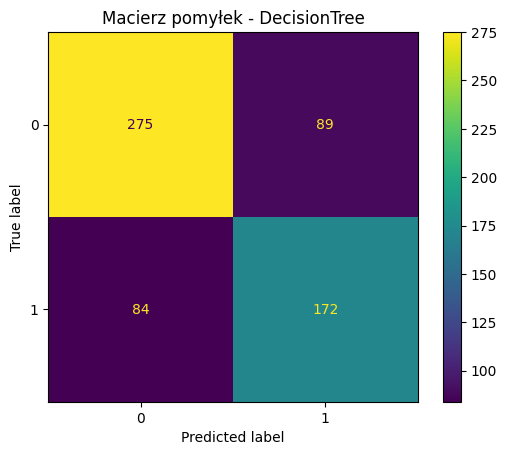

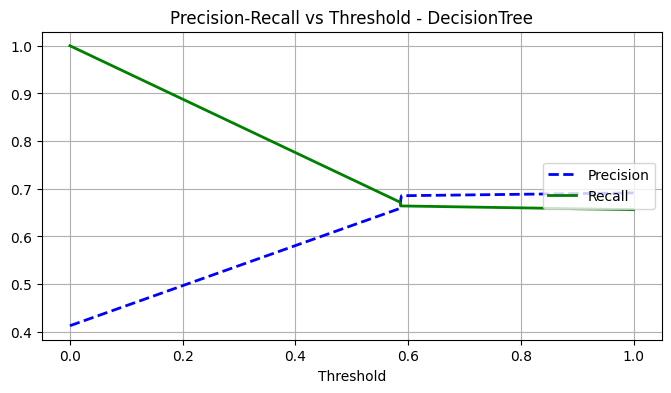

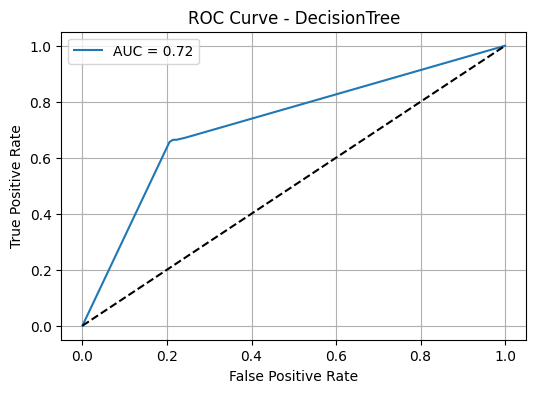


MLPClassifier:
Accuracy (CV): 0.7887528727545612
Precision: 0.7934272300469484
Recall: 0.66015625
F1 Score: 0.720682302771855
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       364
           1       0.79      0.66      0.72       256

    accuracy                           0.79       620
   macro avg       0.79      0.77      0.78       620
weighted avg       0.79      0.79      0.78       620



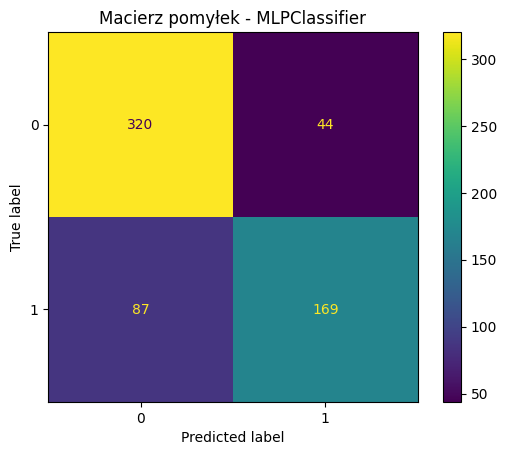

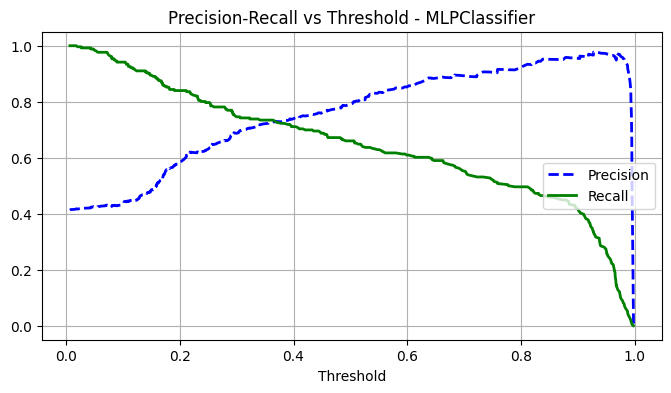

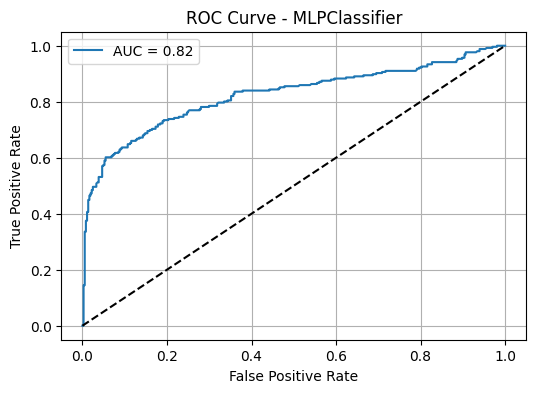


ExtraTreesClassifier:
Accuracy (CV): 0.7451729906352109
Precision: 0.7058823529411765
Recall: 0.65625
F1 Score: 0.680161943319838
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       364
           1       0.71      0.66      0.68       256

    accuracy                           0.75       620
   macro avg       0.74      0.73      0.73       620
weighted avg       0.74      0.75      0.74       620



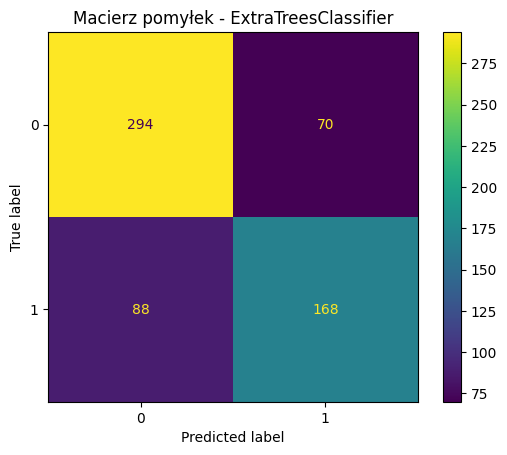

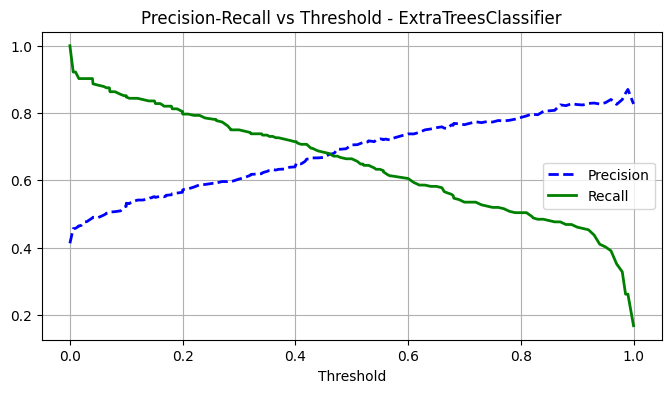

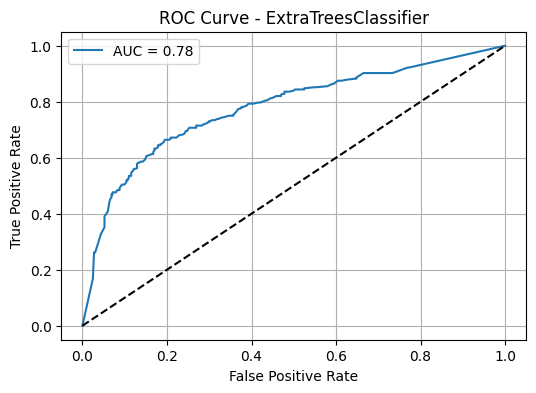


BaggingClassifier:
Accuracy (CV): 0.7564685833997781
Precision: 0.7397260273972602
Recall: 0.6328125
F1 Score: 0.6821052631578948
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       364
           1       0.74      0.63      0.68       256

    accuracy                           0.76       620
   macro avg       0.75      0.74      0.74       620
weighted avg       0.75      0.76      0.75       620



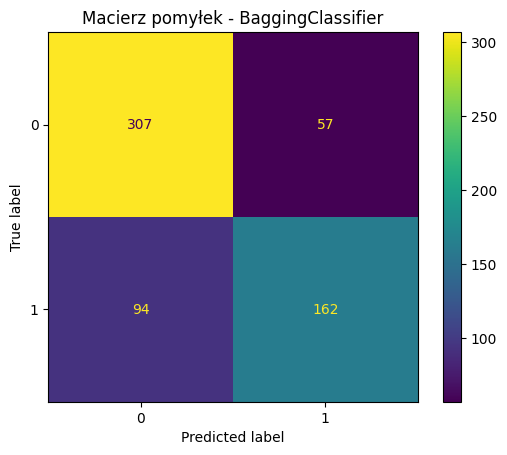

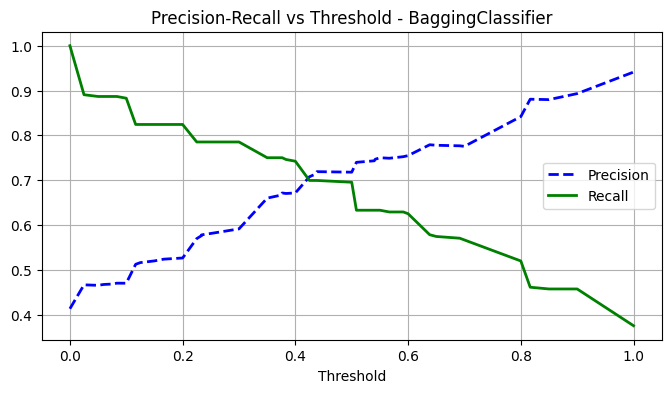

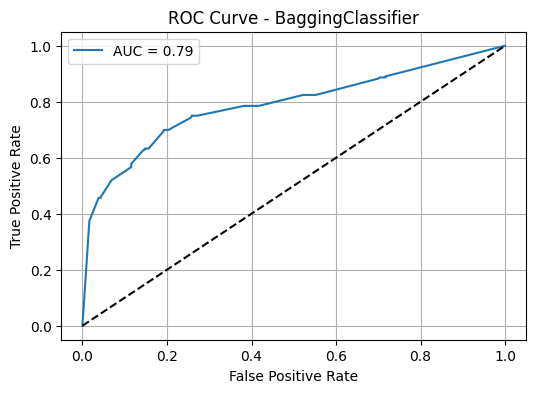


HistGradientBoostingClassifier:
Accuracy (CV): 0.772618545096384
Precision: 0.7327935222672065
Recall: 0.70703125
F1 Score: 0.7196819085487077
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       364
           1       0.73      0.71      0.72       256

    accuracy                           0.77       620
   macro avg       0.77      0.76      0.76       620
weighted avg       0.77      0.77      0.77       620



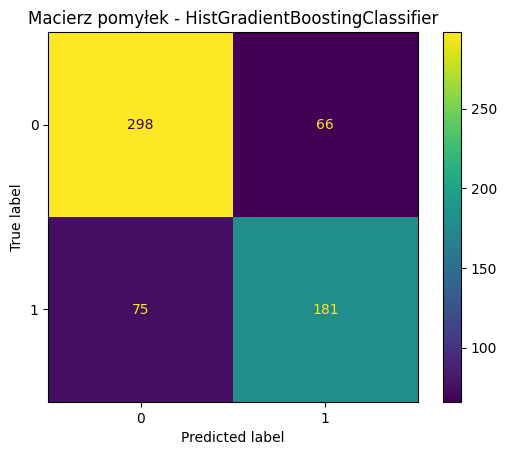

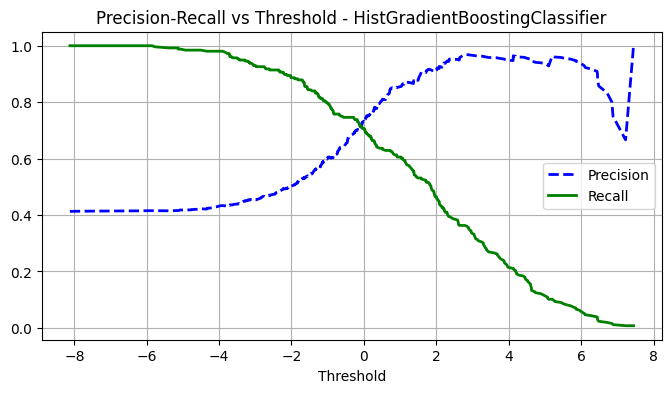

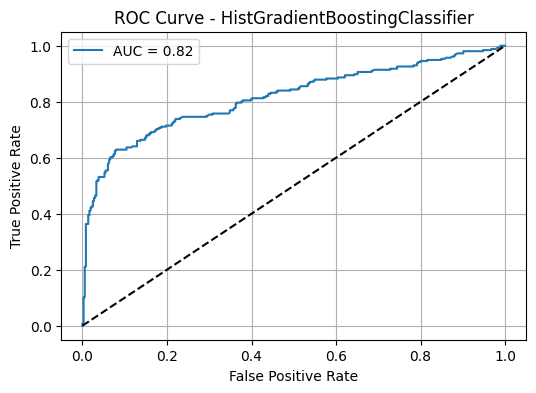


=== Ewaluacja na zbiorze testowym ===

SGDClassifier - Test:
Precision: 0.676056338028169
Recall: 0.75
F1 Score: 0.7111111111111111


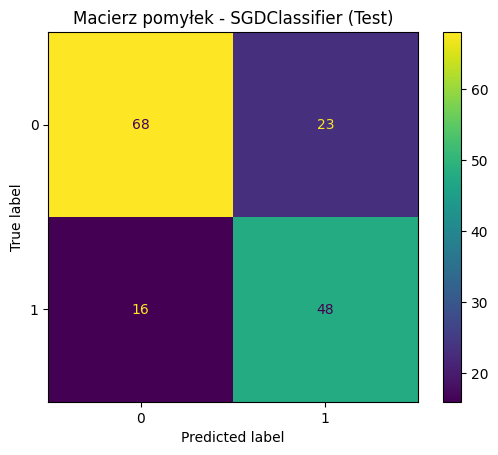


RandomForestClassifier - Test:
Precision: 0.8135593220338984
Recall: 0.75
F1 Score: 0.7804878048780488


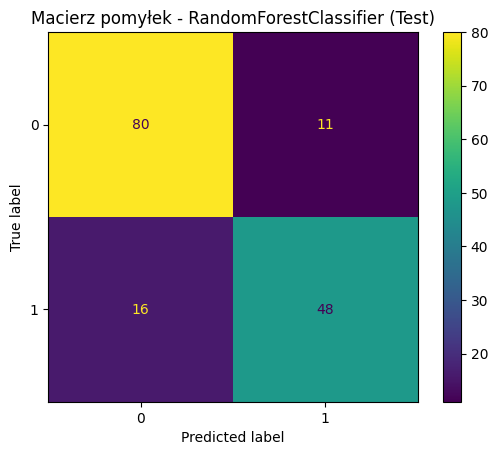


KNeighborsClassifier - Test:
Precision: 0.8103448275862069
Recall: 0.734375
F1 Score: 0.7704918032786885


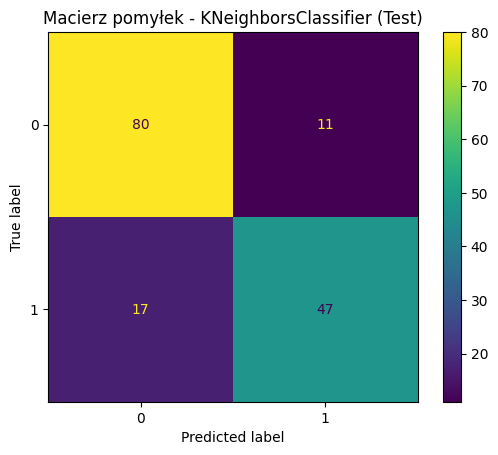


LogisticRegression - Test:
Precision: 0.7
Recall: 0.765625
F1 Score: 0.7313432835820896


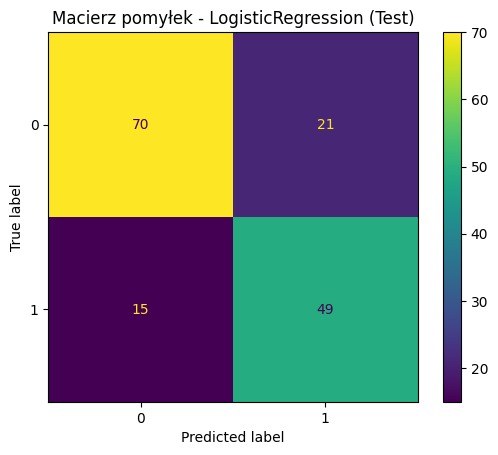


SVC RBF - Test:
Precision: 0.7857142857142857
Recall: 0.6875
F1 Score: 0.7333333333333333


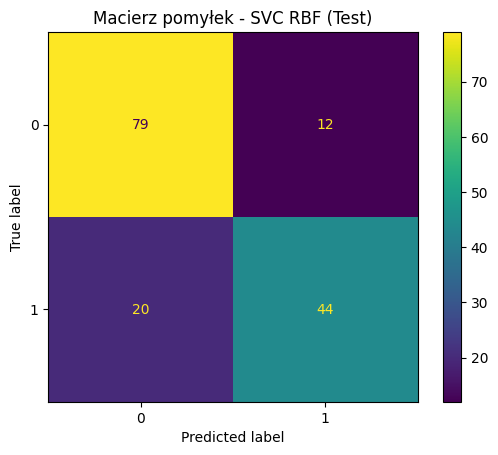


GradientBoostingClassifier - Test:
Precision: 0.8596491228070176
Recall: 0.765625
F1 Score: 0.8099173553719008


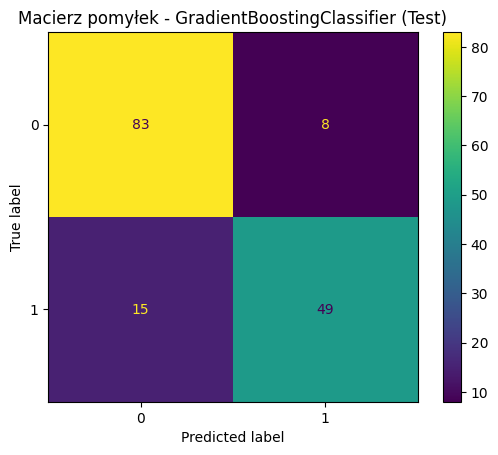


AdaBoostClassifier - Test:
Precision: 0.7164179104477612
Recall: 0.75
F1 Score: 0.732824427480916


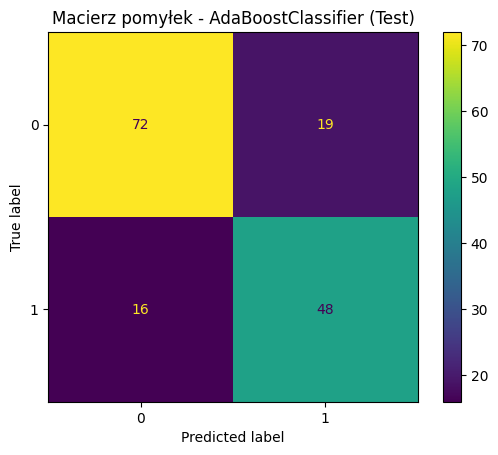


DecisionTree - Test:
Precision: 0.6619718309859155
Recall: 0.734375
F1 Score: 0.6962962962962963


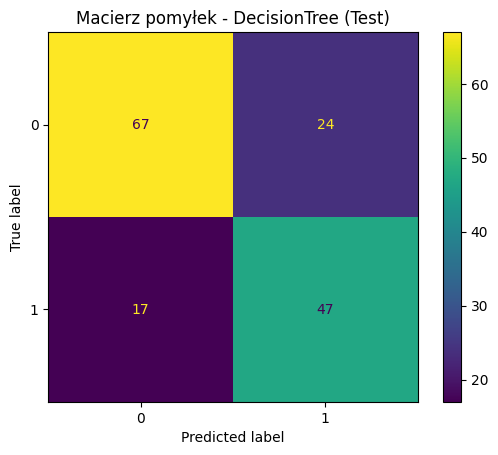


MLPClassifier - Test:
Precision: 0.8301886792452831
Recall: 0.6875
F1 Score: 0.7521367521367521


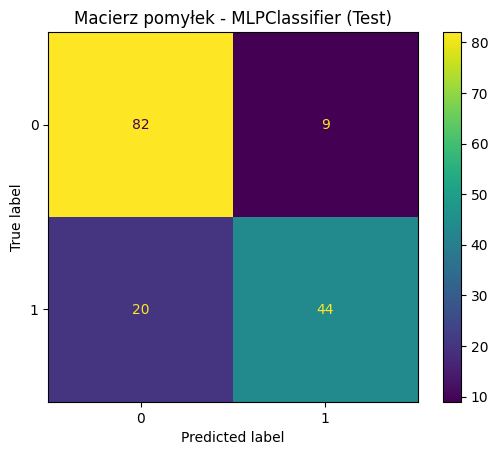


ExtraTreesClassifier - Test:
Precision: 0.7384615384615385
Recall: 0.75
F1 Score: 0.7441860465116279


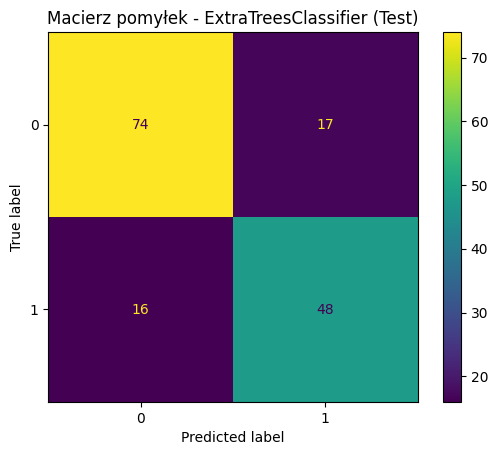


BaggingClassifier - Test:
Precision: 0.8103448275862069
Recall: 0.734375
F1 Score: 0.7704918032786885


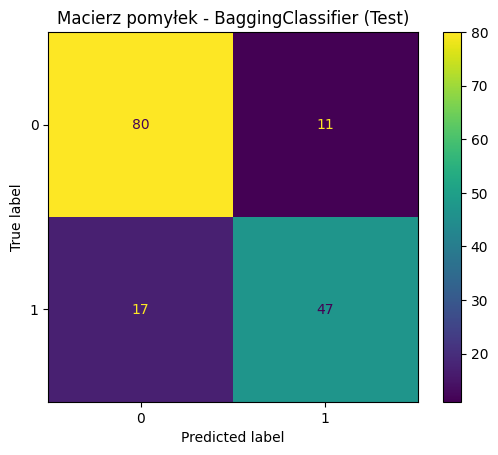


HistGradientBoostingClassifier - Test:
Precision: 0.75
Recall: 0.75
F1 Score: 0.75


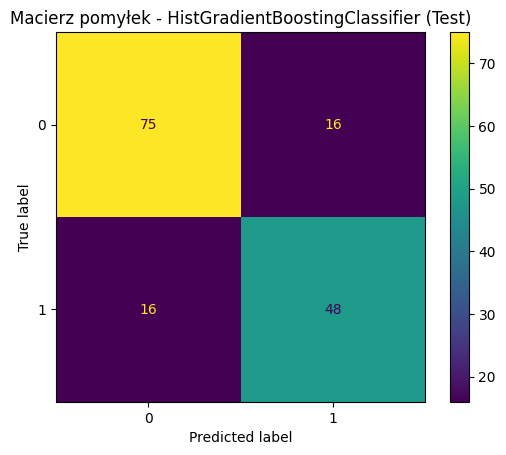

In [ ]:
# 1. Definicje modeli
models = {
    "SGDClassifier": SGDClassifier(random_state=42, class_weight='balanced'),
    "RandomForestClassifier": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "SVC RBF": SVC(kernel="rbf", probability=True, random_state=42, class_weight='balanced'),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "MLPClassifier": MLPClassifier(random_state=42, max_iter=1000),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42, class_weight='balanced'),
    "BaggingClassifier": BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(max_iter=100, random_state=42, class_weight='balanced')
}

# 2. Funkcje pomocnicze
def evaluate_model(name, model):
    print(f"\n{name}:")
    model.fit(X_train, y_train)
    if hasattr(model, "decision_function"):
        y_scores = cross_val_predict(model, X_train, y_train, cv=3, method="decision_function")
    elif hasattr(model, "predict_proba"):
        y_scores = cross_val_predict(model, X_train, y_train, cv=3, method="predict_proba")[:, 1]
    else:
        y_scores = None

    y_pred = cross_val_predict(model, X_train, y_train, cv=3)
    print("Accuracy (CV):", cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy").mean())
    print("Precision:", precision_score(y_train, y_pred))
    print("Recall:", recall_score(y_train, y_pred))
    print("F1 Score:", f1_score(y_train, y_pred))
    print(classification_report(y_train, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_train, y_pred)
    plt.title(f"Macierz pomyłek - {name}")
    plt.show()

    # Precision-Recall
    if y_scores is not None:
        precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)
        plt.figure(figsize=(8, 4))
        plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
        plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
        plt.title(f"Precision-Recall vs Threshold - {name}")
        plt.xlabel("Threshold")
        plt.legend(loc="center right")
        plt.grid()
        plt.show()

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_train, y_scores)
        auc_value = roc_auc_score(y_train, y_scores)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {auc_value:.2f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.grid()
        plt.show()

    return model

def test_evaluation(model, name):
    y_test_pred = model.predict(X_test)
    print(f"\n{name} - Test:")
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1 Score:", f1_score(y_test, y_test_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
    plt.title(f"Macierz pomyłek - {name} (Test)")
    plt.show()

# 3. Trening i ewaluacja każdego modelu
trained_models = {}
for name, model in models.items():
    trained_model = evaluate_model(name, model)
    trained_models[name] = trained_model

# 4. Ocena na zbiorze testowym
print("\n=== Ewaluacja na zbiorze testowym ===")
for name, model in trained_models.items():
    test_evaluation(model, name)

# Wyniki przed optymalizacją

| Model                              | Set        | Accuracy | Precision | Recall   | F1 Score |
| ---------------------------------- | ---------- | -------- | --------- | -------- | -------- |
| **SGDClassifier**                  | Train (CV) | 0.704839 | 0.627178  | 0.703125 | 0.662983 |
|                                    | Test       | 0.748387 | 0.676056  | 0.750000 | 0.711111 |
| **RandomForestClassifier**         | Train (CV) | 0.777419 | 0.765766  | 0.664062 | 0.711297 |
|                                    | Test       | 0.825806 | 0.813559  | 0.750000 | 0.780488 |
| **KNeighborsClassifier**           | Train (CV) | 0.772581 | 0.755556  | 0.664062 | 0.706861 |
|                                    | Test       | 0.819355 | 0.810345  | 0.734375 | 0.770492 |
| **LogisticRegression**             | Train (CV) | 0.761290 | 0.701493  | 0.734375 | 0.717557 |
|                                    | Test       | 0.767742 | 0.700000  | 0.765625 | 0.731343 |
| **SVC RBF**                        | Train (CV) | 0.774194 | 0.752174  | 0.675781 | 0.711934 |
|                                    | Test       | 0.793548 | 0.785714  | 0.687500 | 0.733333 |
| **GradientBoostingClassifier**     | Train (CV) | 0.793548 | 0.804762  | 0.660156 | 0.725322 |
|                                    | Test       | 0.851613 | 0.859649  | 0.765625 | 0.809917 |
| **AdaBoostClassifier**             | Train (CV) | 0.772581 | 0.730924  | 0.710938 | 0.720792 |
|                                    | Test       | 0.774194 | 0.716418  | 0.750000 | 0.732824 |
| **DecisionTree**                   | Train (CV) | 0.720968 | 0.659004  | 0.671875 | 0.665377 |
|                                    | Test       | 0.735484 | 0.661972  | 0.734375 | 0.696296 |
| **MLPClassifier**                  | Train (CV) | 0.788710 | 0.793427  | 0.660156 | 0.720682 |
|                                    | Test       | 0.812903 | 0.830189  | 0.687500 | 0.752137 |
| **ExtraTreesClassifier**           | Train (CV) | 0.745161 | 0.705882  | 0.656250 | 0.680162 |
|                                    | Test       | 0.787097 | 0.738462  | 0.750000 | 0.744186 |
| **BaggingClassifier**              | Train (CV) | 0.756452 | 0.739726  | 0.632812 | 0.682105 |
|                                    | Test       | 0.819355 | 0.810345  | 0.734375 | 0.770492 |
| **HistGradientBoostingClassifier** | Train (CV) | 0.772581 | 0.732794  | 0.707031 | 0.719682 |
|                                    | Test       | 0.793548 | 0.750000  | 0.750000 | 0.750000 |


Przedstawione metryki dotyczą dwóch zestawów danych: treningowego (z walidacją krzyżową) oraz testowego. Mamy tu takie wskaźniki jak accuracy (dokładność), precision (precyzja), recall (czułość) i F1 score (harmoniczną średnią precision i recall).

---

**1. Jakość modeli na zbiorze treningowym (CV)**

* Najwyższe dokładności osiągają modele GradientBoostingClassifier (0.79), MLPClassifier (0.79), RandomForestClassifier (0.78) i SVC RBF (0.77). Są to klasyczne, silne modele uczące się nieliniowych zależności.
* Najsłabszy wynik ma SGDClassifier (0.70), co jest typowe dla prostych klasyfikatorów liniowych bez zaawansowanego strojenia.
* Precyzja (precision) i recall są generalnie zrównoważone, choć dla niektórych modeli precyzja jest wyraźnie niższa niż recall (np. SGDClassifier), co może oznaczać większą liczbę fałszywych alarmów.

---

**2. Wyniki na zbiorze testowym**

* Najlepiej generalizują GradientBoostingClassifier (accuracy 0.85, F1 0.81), RandomForestClassifier (accuracy 0.82, F1 0.78), MLPClassifier (accuracy 0.81, F1 0.75). Te modele radzą sobie najlepiej z nieznanymi danymi.
* SVC RBF, choć na treningu ma wysokie accuracy (0.77), na teście osiąga umiarkowany wynik (accuracy 0.79), co wskazuje na możliwą niewielką utratę dokładności.
* SGDClassifier pozostaje najniżej pod względem skuteczności, z accuracy 0.75 i F1 około 0.71.
* Warto zauważyć, że precyzja i recall utrzymują się na podobnych poziomach jak na treningu, co sugeruje brak dużego overfittingu.

---

**3. Ogólne obserwacje**

* Modele oparte na drzewach (RandomForest, GradientBoosting, ExtraTrees, HistGradientBoosting) mają wyraźnie lepsze wyniki niż prostsze klasyfikatory liniowe czy kNN.
* Wyniki na teście są zauważalnie niższe niż na treningu, ale różnice nie są ekstremalne, co sugeruje umiarkowany overfitting — typowy dla problemów klasyfikacji, ale warto to zredukować w dalszych etapach (np. tuning hiperparametrów, regularizacja, walidacja).
* Modele boostujące (AdaBoost, GradientBoosting) mają generalnie wysoką precyzję i dość wysokie recall, co dobrze rokuje na zastosowania wymagające zrównoważonej klasyfikacji.
* MLPClassifier jest obiecujący, ale ma tendencję do niższego recall na teście w porównaniu do treningu, co warto monitorować.
* BaggingClassifier i ExtraTrees mają niższe wyniki niż ich bardziej zaawansowane odpowiedniki, co wskazuje, że prostsze agregacje mogą być mniej efektywne.

---

# Wyniki po SMOTE ENN

| Model                              | Set        | Accuracy | Precision | Recall   | F1 Score |
| ---------------------------------- | ---------- | -------- | --------- | -------- | -------- |
| **SGDClassifier**                  | Train (CV) | 0.937677 | 0.954545  | 0.935644 | 0.945000 |
|                                    | Test       | 0.913043 | 0.976744  | 0.857143 | 0.913043 |
| **RandomForestClassifier**         | Train (CV) | 0.977337 | 0.970874  | 0.990099 | 0.980392 |
|                                    | Test       | 0.934783 | 1.000000  | 0.877551 | 0.934783 |
| **KNeighborsClassifier**           | Train (CV) | 0.934844 | 0.916279  | 0.975248 | 0.944844 |
|                                    | Test       | 0.934783 | 0.921569  | 0.959184 | 0.940000 |
| **LogisticRegression**             | Train (CV) | 0.943343 | 0.955000  | 0.945545 | 0.950249 |
|                                    | Test       | 0.902174 | 0.976190  | 0.836735 | 0.901099 |
| **SVC RBF**                        | Train (CV) | 0.966006 | 0.979798  | 0.960396 | 0.970000 |
|                                    | Test       | 0.913043 | 1.000000  | 0.836735 | 0.911111 |
| **GradientBoostingClassifier**     | Train (CV) | 0.980170 | 0.980296  | 0.985149 | 0.982716 |
|                                    | Test       | 0.923913 | 1.000000  | 0.857143 | 0.923077 |
| **AdaBoostClassifier**             | Train (CV) | 0.971671 | 0.966019  | 0.985149 | 0.975490 |
|                                    | Test       | 0.956522 | 1.000000  | 0.918367 | 0.957447 |
| **DecisionTree**                   | Train (CV) | 0.974504 | 0.966184  | 0.990099 | 0.977995 |
|                                    | Test       | 0.934783 | 1.000000  | 0.877551 | 0.934783 |
| **MLPClassifier**                  | Train (CV) | 0.980170 | 0.975610  | 0.990099 | 0.982801 |
|                                    | Test       | 0.913043 | 0.976744  | 0.857143 | 0.913043 |
| **ExtraTreesClassifier**           | Train (CV) | 0.977337 | 0.975490  | 0.985149 | 0.980296 |
|                                    | Test       | 0.902174 | 1.000000  | 0.816327 | 0.898876 |
| **BaggingClassifier**              | Train (CV) | 0.980170 | 0.985075  | 0.980198 | 0.982630 |
|                                    | Test       | 0.934783 | 1.000000  | 0.877551 | 0.934783 |
| **HistGradientBoostingClassifier** | Train (CV) | 0.963173 | 0.956522  | 0.980198 | 0.968215 |
|                                    | Test       | 0.934783 | 1.000000  | 0.877551 | 0.934783 |


Wynik w tabeli dotyczą działania modeli po zastosowaniu techniki SMOTE ENN. Ta metoda łączy oversampling (SMOTE) z undersamplingiem (ENN) i ma na celu poprawę jakości danych przez zbalansowanie klas oraz usunięcie punktów granicznych, co zazwyczaj przekłada się na lepsze wyniki modeli, zwłaszcza w problemach z nierównomiernym rozkładem klas.

---

### 1. Jakość modeli na zbiorze treningowym (walidacja krzyżowa)

* **Wysokie dokładności i F1 Score** widzimy praktycznie dla wszystkich modeli — większość ma accuracy powyżej 0.95, a F1 Score blisko 0.95 i wyżej. To wskazuje na bardzo dobrą zdolność modeli do dopasowania się do danych treningowych.
* Modele takie jak GradientBoostingClassifier, MLPClassifier, BaggingClassifier oraz RandomForestClassifier osiągają accuracy powyżej 0.97, a F1 Score blisko 0.98, co jest bardzo dobrym wynikiem.
* Warto podkreślić, że nawet prostszy model SGDClassifier ma tu wysokie wyniki na treningu, co świadczy o tym, że SMOTE ENN pomogło uczynić problem bardziej liniowo separowalnym.

---

### 2. Wyniki na zbiorze testowym

* Dokładności testowe są bardzo wysokie i utrzymują się około 0.91–0.95, a w przypadku AdaBoostClassifier nawet 0.956. To znaczny wzrost względem wyników sprzed SMOTE ENN (poprzednia tabela).
* Modele drzewiaste i boostujące (RandomForest, GradientBoosting, AdaBoost, DecisionTree, Bagging, HistGradientBoosting) generalnie uzyskują najlepsze wyniki — zarówno pod względem accuracy, jak i F1 Score (około 0.93–0.95), co świadczy o poprawionej generalizacji.
* Czułość (recall) jest na ogół wyższa niż w wersji przed SMOTE ENN, co sugeruje, że modele lepiej wykrywają przypadki pozytywne — typowo problematyczne przy niezbalansowanych danych.
* Precyzja pozostaje na wysokim poziomie, często równa lub bliska 1.0, co oznacza, że modele popełniają niewiele fałszywych alarmów.

---

### 3. Wnioski i interpretacja

* Zastosowanie SMOTE ENN bardzo pozytywnie wpłynęło na skuteczność klasyfikatorów. Poprawa jest szczególnie widoczna w recall i F1 Score na zbiorze testowym, co jest ważne w przypadku problemów, gdzie zbalansowanie klas i eliminacja szumu są kluczowe.
* Modele oparte na drzewach oraz boostingach zdecydowanie zyskały, co sugeruje, że te metody najlepiej wykorzystują przetworzone dane.
* Wzrost wyników SGDClassifier wskazuje, że techniki balansowania klas ułatwiły również zadania modelom liniowym.
* Brak dużej różnicy między wynikami na treningu a testem pokazuje, że SMOTE ENN pomogło również w redukcji overfittingu.
* Wysoka precyzja i recall oznaczają, że modele po takim preprocessing’u są skuteczne zarówno w wykrywaniu prawdziwych pozytywów, jak i w unikaniu fałszywych alarmów.

---


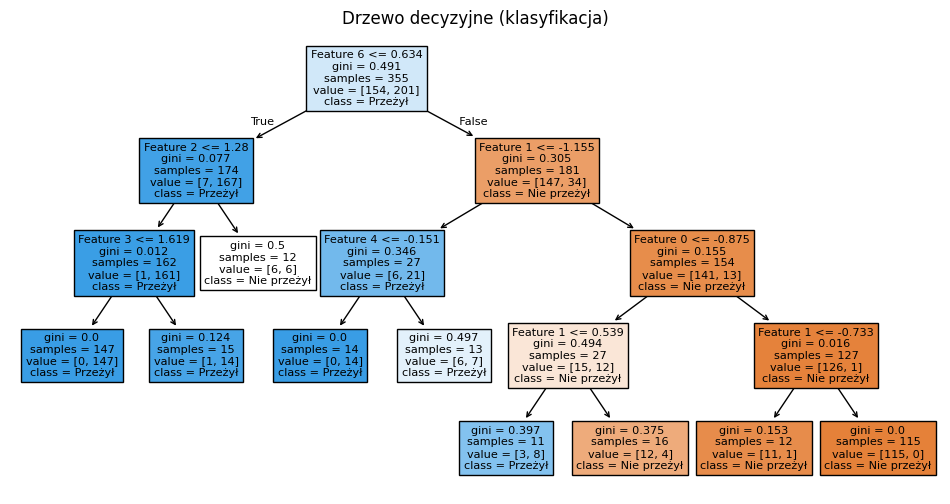

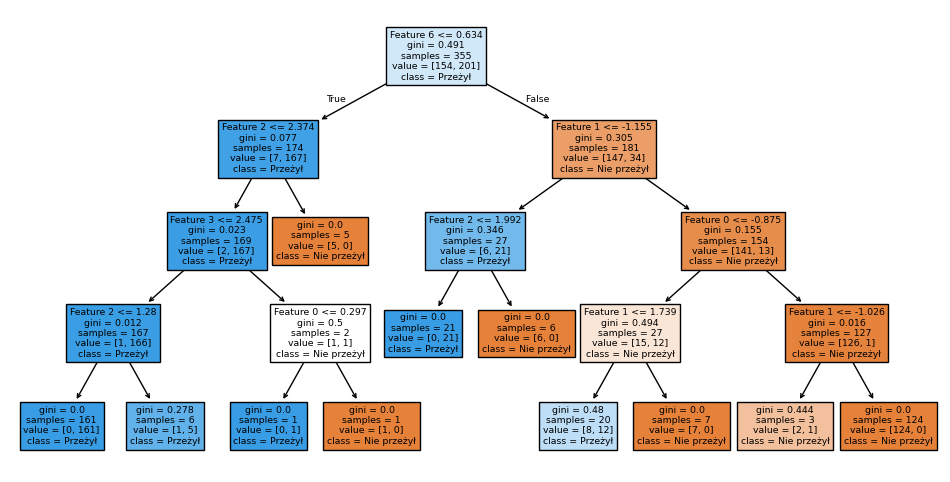

Dokładność clf1: 0.9166666666666666
Dokładność clf2: 0.9166666666666666


In [ ]:
class_names=['Nie przeżył', 'Przeżył']

# Trenowanie drzewa decyzyjnego (CART) dla klasyfikacji
clf1 = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42, min_samples_split=10 ,min_samples_leaf=10)
clf2 = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf3 = RandomForestClassifier(criterion='gini', max_depth=4, random_state=42)
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)
clf3.fit(X_train, y_train)

# Wizualizacja drzewa decyzyjnego
plt.figure(figsize=(12, 6))
tree.plot_tree(clf1, filled=True, feature_names=[f"Feature {i}" for i in range(X_train.shape[1])], class_names=['Nie przeżył', 'Przeżył'])
plt.title('Drzewo decyzyjne (klasyfikacja)')
plt.show()
plt.figure(figsize=(12, 6))
tree.plot_tree(clf2, filled=True, feature_names=[f"Feature {i}" for i in range(X_train.shape[1])], class_names=['Nie przeżył', 'Przeżył'])
plt.show()

from sklearn.metrics import accuracy_score

y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Dokładność clf1:", accuracy_score(y_test, y_pred1))
print("Dokładność clf2:", accuracy_score(y_test, y_pred2))

## Optymalizacja

### Inżynieria cech

In [ ]:
def create_features(df):
    df = df.copy()

    # FamilySize
    df['FamilySize'] = df['sibsp'] + df['parch']

    # Age group
    df['AgeGroup'] = pd.cut(df['age'],
                            bins=[0, 12, 18, 35, 60, 120],
                            labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

    # Fare band (np. kwantyle)
    df['FareBand'] = pd.qcut(df['fare'], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'])

    return df

df = create_features(df)
# Kodowanie cech kategorycznych
df = pd.get_dummies(df, columns=['sex', 'embarked', 'class', 'AgeGroup', 'FareBand'], drop_first=True)

Ten kod tworzy nowe cechy na podstawie istniejącego DataFrame `df` i koduje kategorie na wartości numeryczne gotowe do modelowania. Funkcja `create_features`:

* dodaje kolumnę `FamilySize` jako sumę liczby rodzeństwa/partnerów (`sibsp`) i rodziców/dzieci (`parch`),
* dzieli wiek (`age`) na grupy wiekowe (`AgeGroup`) takie jak dziecko, nastolatek, młody dorosły, dorosły, senior,
* dzieli cenę biletu (`fare`) na cztery kategorie (`FareBand`) według kwartyli.

Następnie, poza funkcją, zmienne kategoryczne (`sex`, `embarked`, `class`, `AgeGroup`, `FareBand`) są kodowane na zmienne zero-jedynkowe (`dummy variables`), a jedna kategoria jest pomijana (`drop_first=True`), by uniknąć kolinearności.

Etap ten będzie pominięty ze względu na brak poprawy a nawet pogorszenie wyników.

Future importances

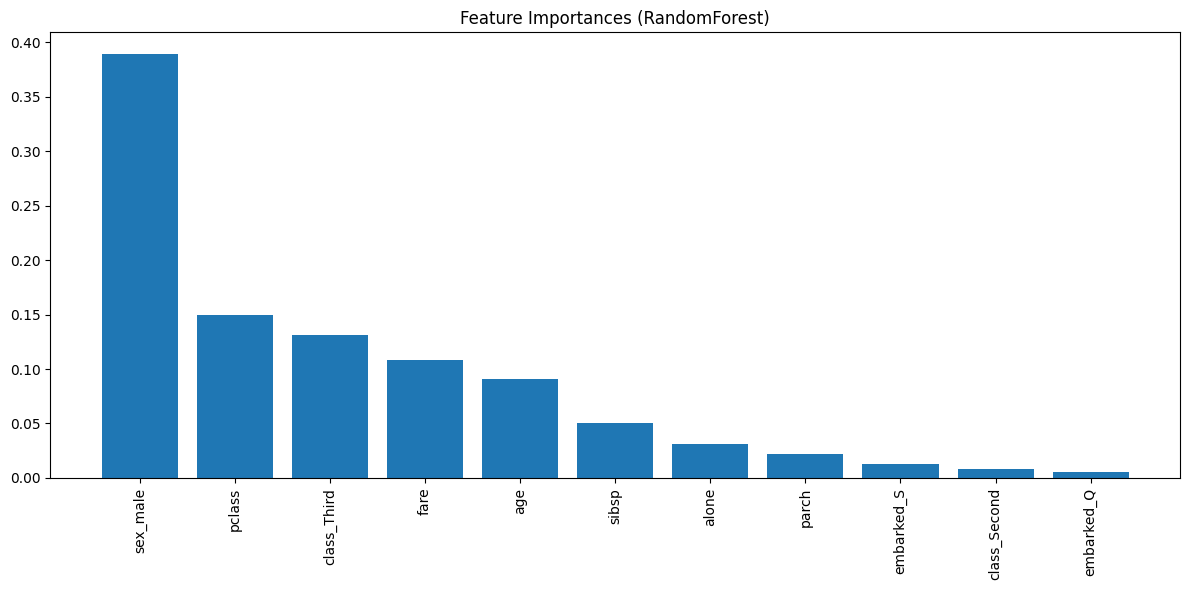

In [ ]:
# Zakładamy, że masz już wytrenowany clf i X_train
importances = clf3.feature_importances_
feature_names = X_train.columns

# Posortuj wg ważności
indices = np.argsort(importances)[::-1]

# Wykres
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (RandomForest)")
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

Najważniejsze cechy według RandomForest to:
- Sex_male
- pclass
- class_Third
- fare
- age

 ### SMOTE + undersampling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features_scaled_df, target, stratify=target, test_size=0.2, random_state=42)

# Inicjalizacja metody łączącej oversampling SMOTE i undersampling ENN
smote_enn = SMOTEENN(random_state=42)

# Przekształcenie danych treningowych
X_train, y_train = smote_enn.fit_resample(X_train, y_train)
X_test, y_test = smote_enn.fit_resample(X_test, y_test)

print(f"Przed SMOTEENN: {y_train.value_counts().to_dict()}")
print(f"Po SMOTEENN: {pd.Series(y_train).value_counts().to_dict()}")

Przed SMOTEENN: {1: 202, 0: 151}
Po SMOTEENN: {1: 202, 0: 151}


 Kod używa metody SMOTEENN, która łączy oversampling (SMOTE) i undersampling (ENN), aby zbalansować klasy w obu zbiorach. Po transformacji wyświetla liczbę przykładów każdej klasy przed i po zastosowaniu SMOTEENN, pokazując efekt zbalansowania danych.

### Hyperparameter tuning

Ten kod służy do porównawczej oceny różnych klasyfikatorów na danych treningowych i testowych, z użyciem strojenia hiperparametrów i kompleksowej ewaluacji metryk.

Zmienna `models` zawiera słownik 12 klasyfikatorów z biblioteki `scikit-learn`, takich jak `RandomForestClassifier`, `SVC`, `MLPClassifier`, `GradientBoostingClassifier` itd., z uwzględnieniem różnych strategii uczenia (drzewa, boosting, sieci neuronowe, metoda SGD itp.). Dla większości z nich ustawiono `class_weight='balanced'`, aby przeciwdziałać niezrównoważonym klasom.

Zmienna `param_dists` zawiera zestaw przestrzeni hiperparametrów do strojenia dla każdego modelu. Te parametry będą losowo przeszukiwane w ramach `RandomizedSearchCV`.

Zmienna `cv` to 5-krotna walidacja krzyżowa z uwzględnieniem proporcji klas (`StratifiedKFold`), a `scorer` to niestandardowa metryka oparta na F1-score.

Funkcja `evaluate_model_full` wykonuje pełny pipeline:

1. Tworzy `Pipeline`, który składa się ze skalowania cech (`StandardScaler`) i wybranego modelu.
2. Przeprowadza strojenie hiperparametrów za pomocą `RandomizedSearchCV` (20 losowych kombinacji).
3. Wyświetla najlepsze parametry i średni wynik F1 ze zbioru treningowego (walidacja krzyżowa).
4. Oblicza predykcje na treningowym zbiorze CV i drukuje metryki klasyfikacyjne oraz macierz pomyłek.
5. Jeśli model pozwala na obliczenie prawdopodobieństwa lub decision function, generuje wykresy Precision-Recall i ROC wraz z wartością AUC.
6. Następnie ewaluowany jest ten sam, najlepiej dostrojony model na zbiorze testowym – również z metrykami i macierzą pomyłek.

Ostatecznie w pętli `for` wszystkie modele są trenowane, strojenie jest wykonywane dla każdego z osobna, a zwrócone najlepiej dopasowane modele są przechowywane w słowniku `trained_models`.



*** Strojenie modelu: SGDClassifier ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__penalty': 'l2', 'clf__max_iter': 1000, 'clf__loss': 'modified_huber', 'clf__alpha': 0.0001}
Średni wynik F1 (CV): 0.9629
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9575070821529745
Precision: 0.9605911330049262
Recall: 0.9653465346534653
F1 Score: 0.9629629629629629
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       151
           1       0.96      0.97      0.96       202

    accuracy                           0.96       353
   macro avg       0.96      0.96      0.96       353
weighted avg       0.96      0.96      0.96       353



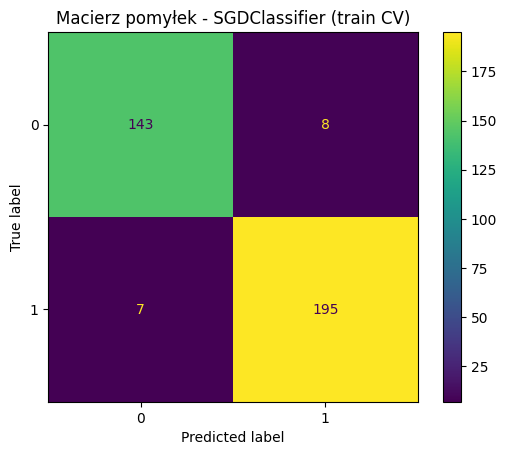

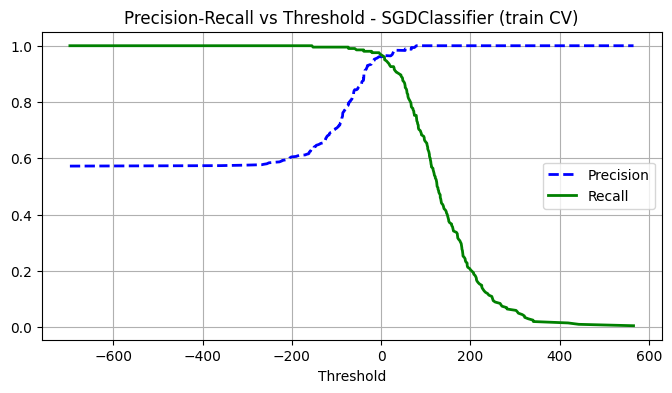

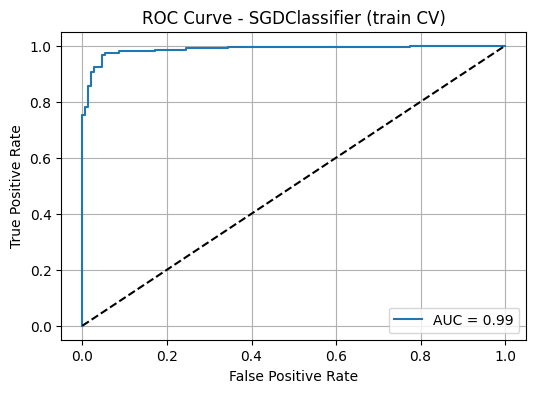

Wyniki na zbiorze testowym dla SGDClassifier:
Accuracy: 0.9130434782608695
Precision: 0.9767441860465116
Recall: 0.8571428571428571
F1 Score: 0.9130434782608695
              precision    recall  f1-score   support

           0       0.86      0.98      0.91        43
           1       0.98      0.86      0.91        49

    accuracy                           0.91        92
   macro avg       0.92      0.92      0.91        92
weighted avg       0.92      0.91      0.91        92



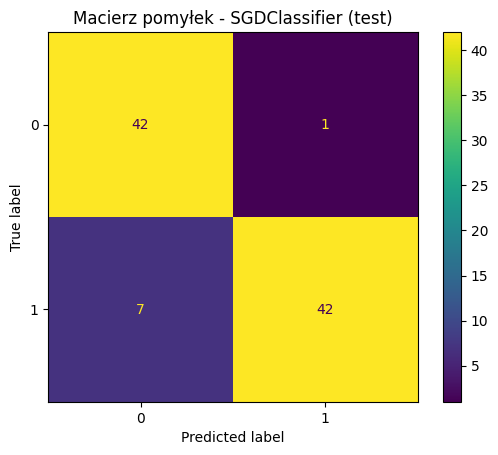


*** Strojenie modelu: RandomForestClassifier ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 10}
Średni wynik F1 (CV): 0.9900
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9886685552407932
Precision: 0.9900990099009901
Recall: 0.9900990099009901
F1 Score: 0.9900990099009901
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       151
           1       0.99      0.99      0.99       202

    accuracy                           0.99       353
   macro avg       0.99      0.99      0.99       353
weighted avg       0.99      0.99      0.99       353



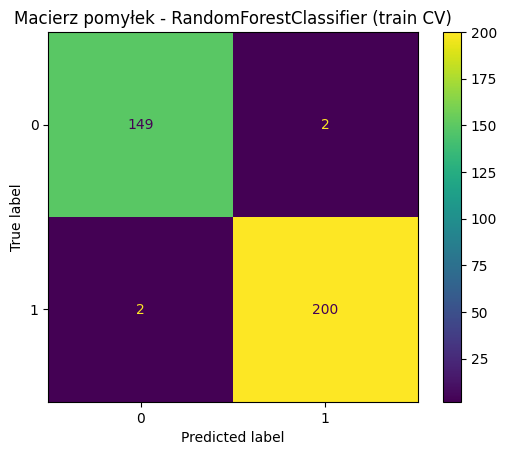

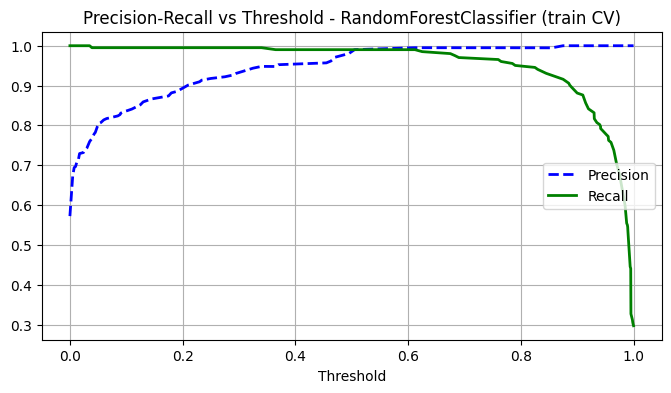

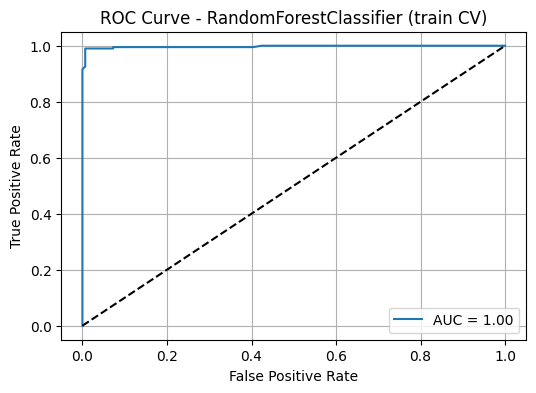

Wyniki na zbiorze testowym dla RandomForestClassifier:
Accuracy: 0.9239130434782609
Precision: 1.0
Recall: 0.8571428571428571
F1 Score: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        43
           1       1.00      0.86      0.92        49

    accuracy                           0.92        92
   macro avg       0.93      0.93      0.92        92
weighted avg       0.93      0.92      0.92        92



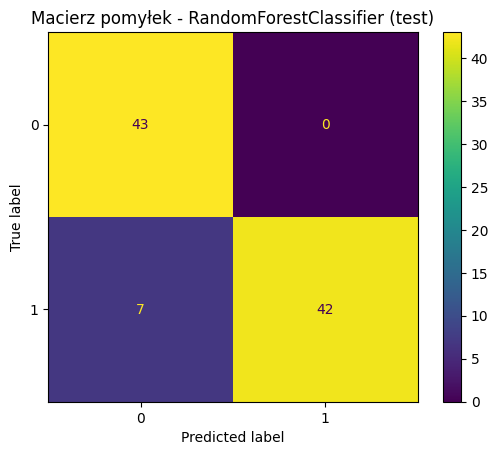


*** Strojenie modelu: KNeighborsClassifier ***
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Najlepsze parametry: {'clf__weights': 'distance', 'clf__p': 1, 'clf__n_neighbors': 3}
Średni wynik F1 (CV): 0.9760
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9716713881019831
Precision: 0.9571428571428572
Recall: 0.995049504950495
F1 Score: 0.9757281553398058
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       151
           1       0.96      1.00      0.98       202

    accuracy                           0.97       353
   macro avg       0.98      0.97      0.97       353
weighted avg       0.97      0.97      0.97       353



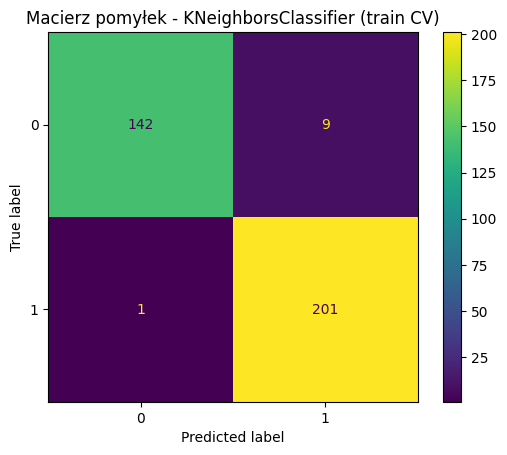

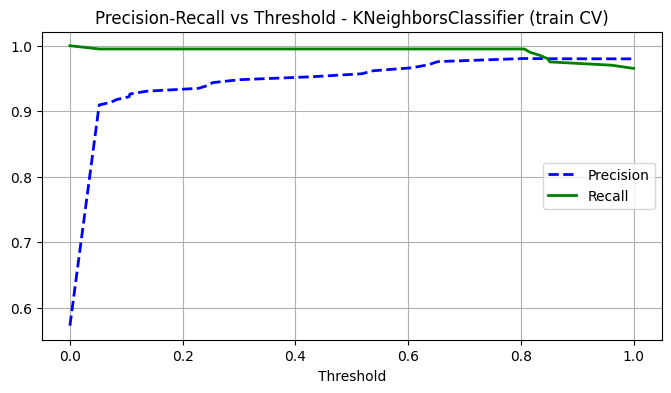

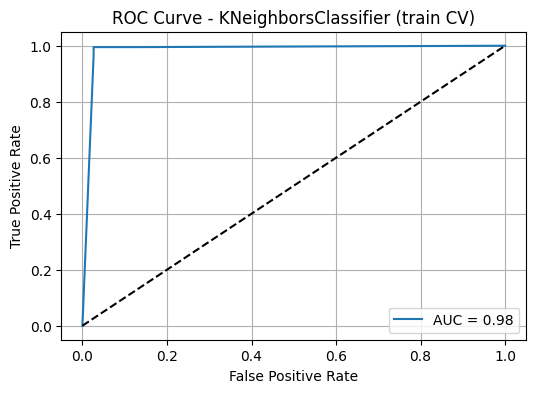

Wyniki na zbiorze testowym dla KNeighborsClassifier:
Accuracy: 0.9565217391304348
Precision: 0.9591836734693877
Recall: 0.9591836734693877
F1 Score: 0.9591836734693877
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.96      0.96      0.96        49

    accuracy                           0.96        92
   macro avg       0.96      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



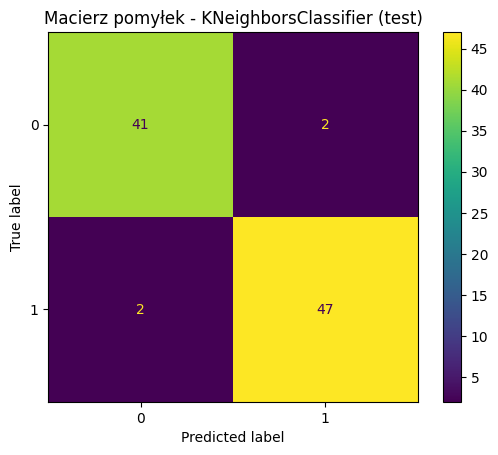


*** Strojenie modelu: LogisticRegression ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_

Najlepsze parametry: {'clf__solver': 'saga', 'clf__penalty': 'l2', 'clf__l1_ratio': 0.5, 'clf__C': 0.1}
Średni wynik F1 (CV): 0.9570
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9518413597733711
Precision: 0.9743589743589743
Recall: 0.9405940594059405
F1 Score: 0.9571788413098237
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       151
           1       0.97      0.94      0.96       202

    accuracy                           0.95       353
   macro avg       0.95      0.95      0.95       353
weighted avg       0.95      0.95      0.95       353



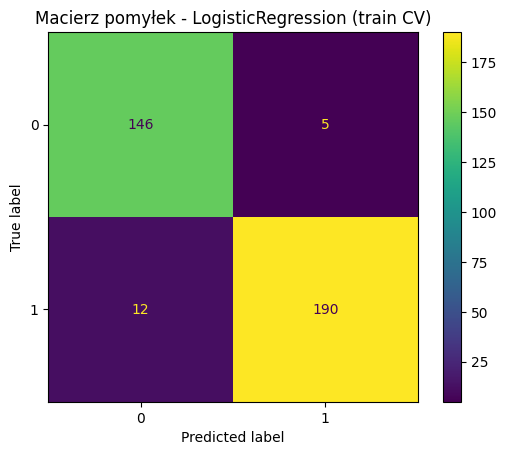

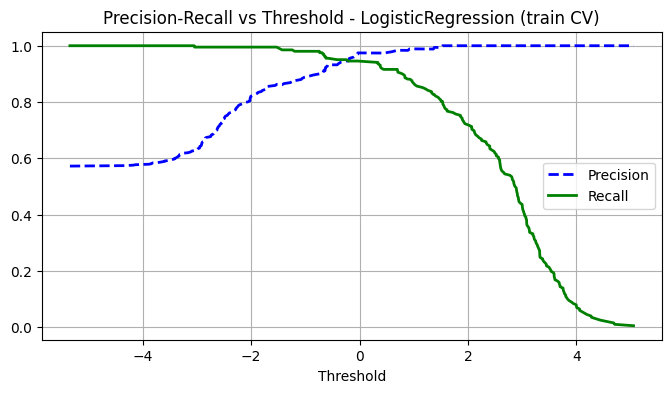

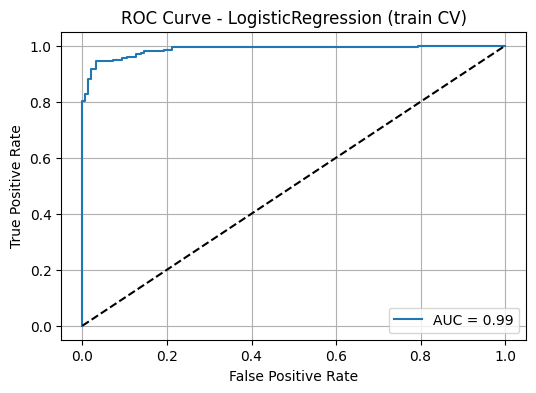

Wyniki na zbiorze testowym dla LogisticRegression:
Accuracy: 0.9239130434782609
Precision: 1.0
Recall: 0.8571428571428571
F1 Score: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        43
           1       1.00      0.86      0.92        49

    accuracy                           0.92        92
   macro avg       0.93      0.93      0.92        92
weighted avg       0.93      0.92      0.92        92



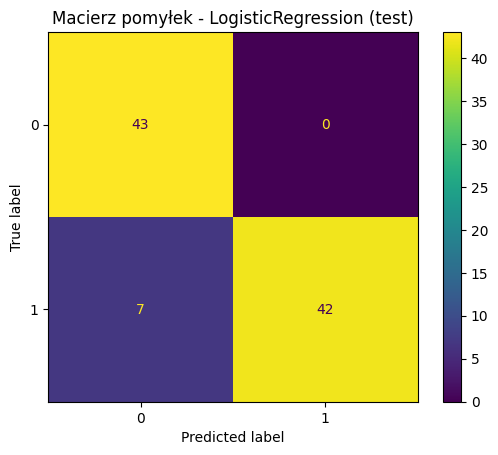


*** Strojenie modelu: SVC RBF ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__gamma': 'scale', 'clf__C': 100}
Średni wynik F1 (CV): 0.9828
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9801699716713881
Precision: 0.975609756097561
Recall: 0.9900990099009901
F1 Score: 0.9828009828009828
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       151
           1       0.98      0.99      0.98       202

    accuracy                           0.98       353
   macro avg       0.98      0.98      0.98       353
weighted avg       0.98      0.98      0.98       353



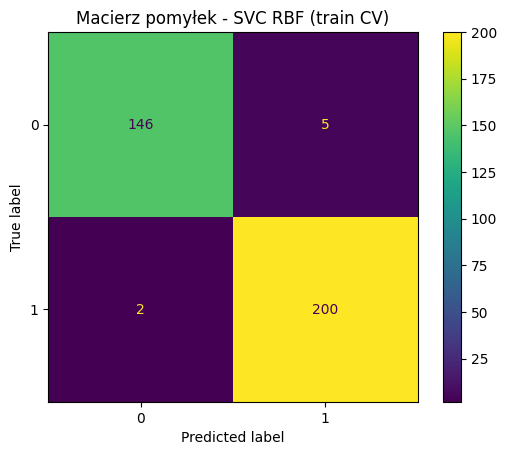

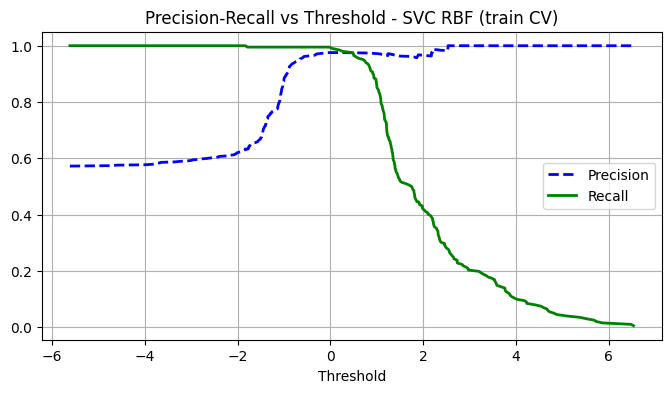

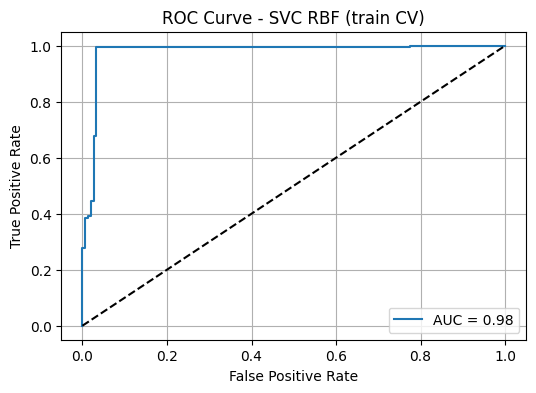

Wyniki na zbiorze testowym dla SVC RBF:
Accuracy: 0.9565217391304348
Precision: 1.0
Recall: 0.9183673469387755
F1 Score: 0.9574468085106383
              precision    recall  f1-score   support

           0       0.91      1.00      0.96        43
           1       1.00      0.92      0.96        49

    accuracy                           0.96        92
   macro avg       0.96      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



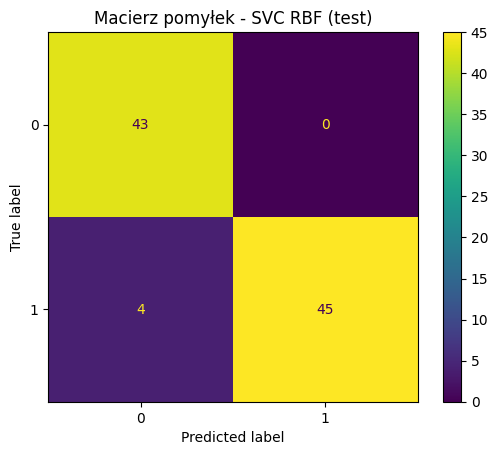


*** Strojenie modelu: GradientBoostingClassifier ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__n_estimators': 100, 'clf__max_depth': 5, 'clf__learning_rate': 0.1}
Średni wynik F1 (CV): 0.9852
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9830028328611898
Precision: 0.9803921568627451
Recall: 0.9900990099009901
F1 Score: 0.9852216748768473
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       151
           1       0.98      0.99      0.99       202

    accuracy                           0.98       353
   macro avg       0.98      0.98      0.98       353
weighted avg       0.98      0.98      0.98       353



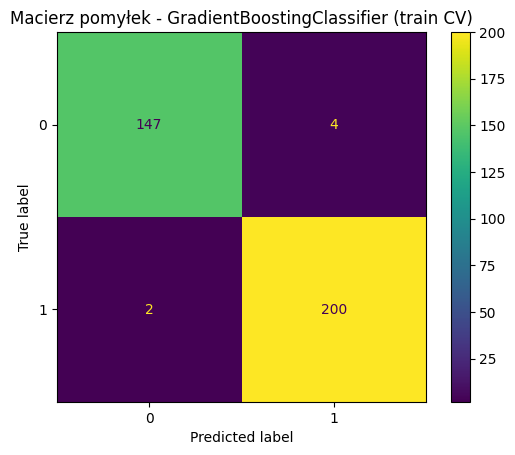

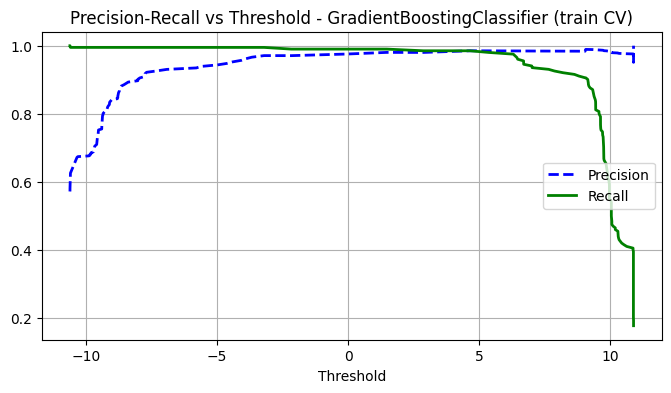

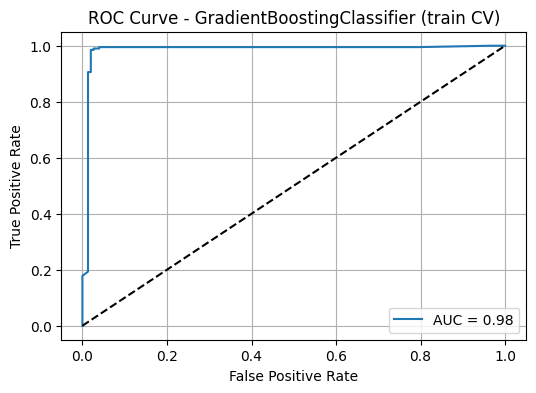

Wyniki na zbiorze testowym dla GradientBoostingClassifier:
Accuracy: 0.9130434782608695
Precision: 1.0
Recall: 0.8367346938775511
F1 Score: 0.9111111111111111
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        43
           1       1.00      0.84      0.91        49

    accuracy                           0.91        92
   macro avg       0.92      0.92      0.91        92
weighted avg       0.93      0.91      0.91        92



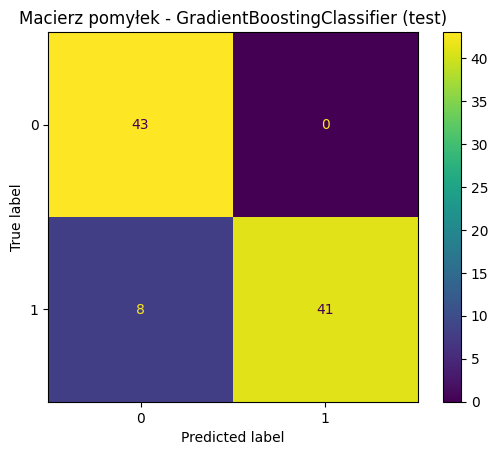


*** Strojenie modelu: AdaBoostClassifier ***
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Najlepsze parametry: {'clf__n_estimators': 50, 'clf__learning_rate': 1.0}
Średni wynik F1 (CV): 0.9779
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9745042492917847
Precision: 0.9707317073170731
Recall: 0.9851485148514851
F1 Score: 0.9778869778869779
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       151
           1       0.97      0.99      0.98       202

    accuracy                           0.97       353
   macro avg       0.98      0.97      0.97       353
weighted avg       0.97      0.97      0.97       353



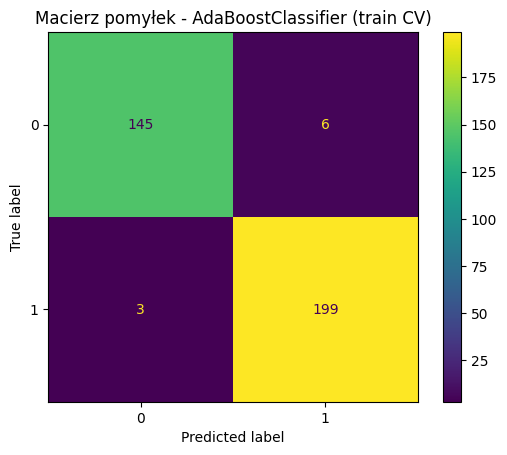

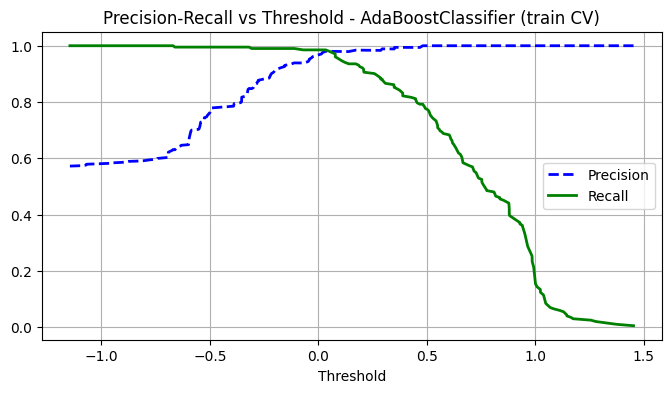

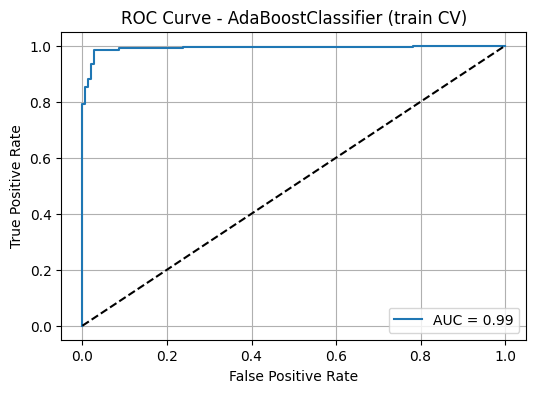

Wyniki na zbiorze testowym dla AdaBoostClassifier:
Accuracy: 0.9565217391304348
Precision: 1.0
Recall: 0.9183673469387755
F1 Score: 0.9574468085106383
              precision    recall  f1-score   support

           0       0.91      1.00      0.96        43
           1       1.00      0.92      0.96        49

    accuracy                           0.96        92
   macro avg       0.96      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



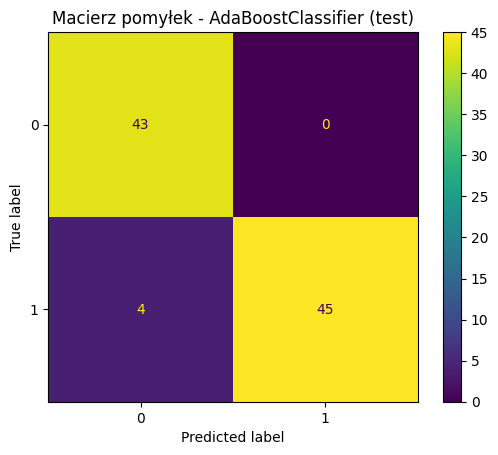


*** Strojenie modelu: DecisionTree ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 5}
Średni wynik F1 (CV): 0.9877
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9858356940509915
Precision: 0.9852216748768473
Recall: 0.9900990099009901
F1 Score: 0.9876543209876543
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       151
           1       0.99      0.99      0.99       202

    accuracy                           0.99       353
   macro avg       0.99      0.99      0.99       353
weighted avg       0.99      0.99      0.99       353



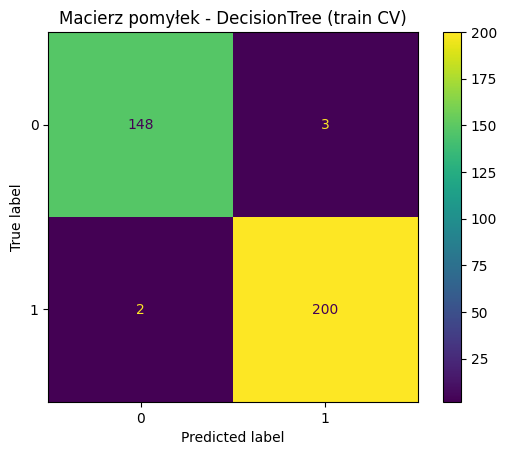

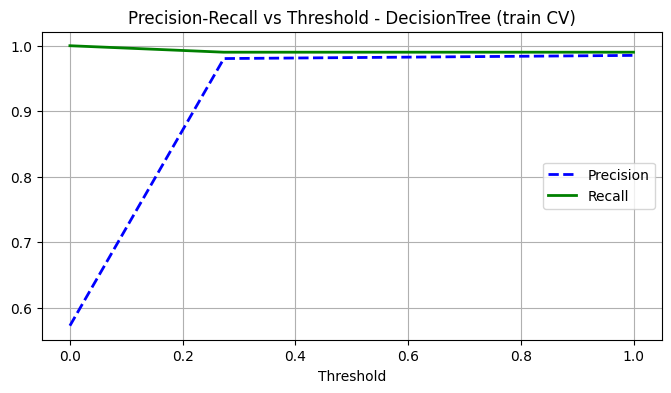

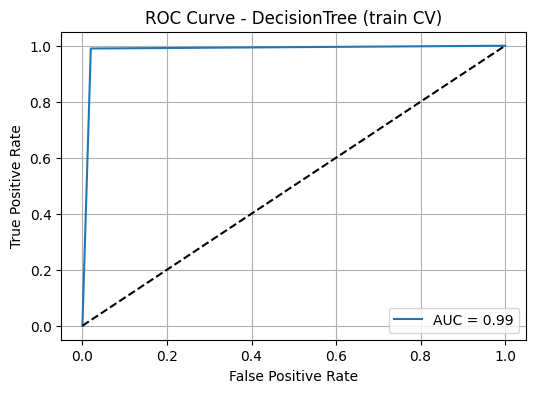

Wyniki na zbiorze testowym dla DecisionTree:
Accuracy: 0.9130434782608695
Precision: 1.0
Recall: 0.8367346938775511
F1 Score: 0.9111111111111111
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        43
           1       1.00      0.84      0.91        49

    accuracy                           0.91        92
   macro avg       0.92      0.92      0.91        92
weighted avg       0.93      0.91      0.91        92



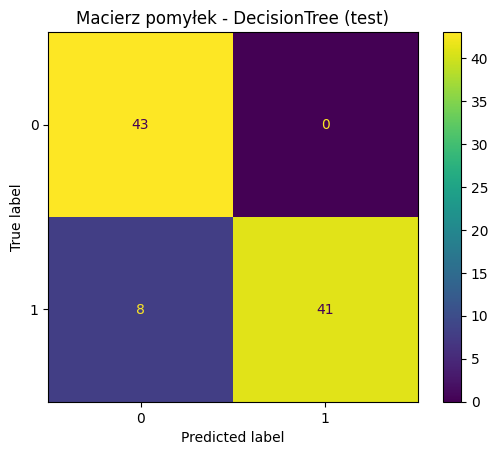


*** Strojenie modelu: MLPClassifier ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__solver': 'adam', 'clf__learning_rate': 'constant', 'clf__hidden_layer_sizes': (50,), 'clf__alpha': 0.0001, 'clf__activation': 'relu'}
Średni wynik F1 (CV): 0.9829
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9801699716713881
Precision: 0.9710144927536232
Recall: 0.995049504950495
F1 Score: 0.9828850855745721
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       151
           1       0.97      1.00      0.98       202

    accuracy                           0.98       353
   macro avg       0.98      0.98      0.98       353
weighted avg       0.98      0.98      0.98       353



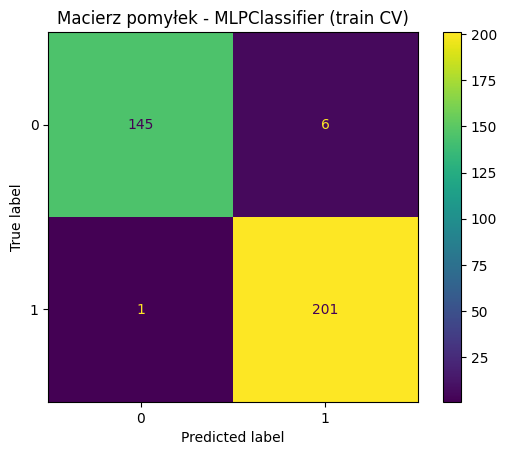

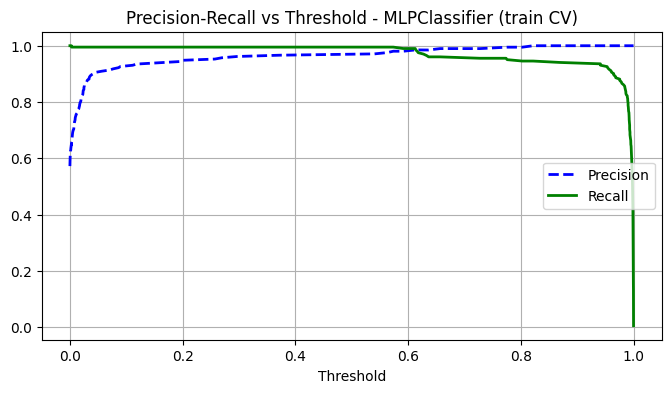

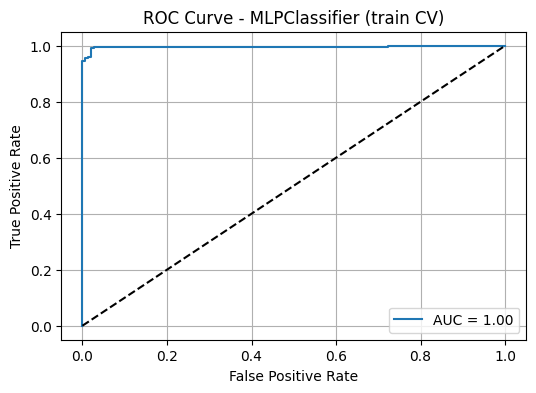

Wyniki na zbiorze testowym dla MLPClassifier:
Accuracy: 0.9347826086956522
Precision: 0.9777777777777777
Recall: 0.8979591836734694
F1 Score: 0.9361702127659575
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        43
           1       0.98      0.90      0.94        49

    accuracy                           0.93        92
   macro avg       0.94      0.94      0.93        92
weighted avg       0.94      0.93      0.93        92



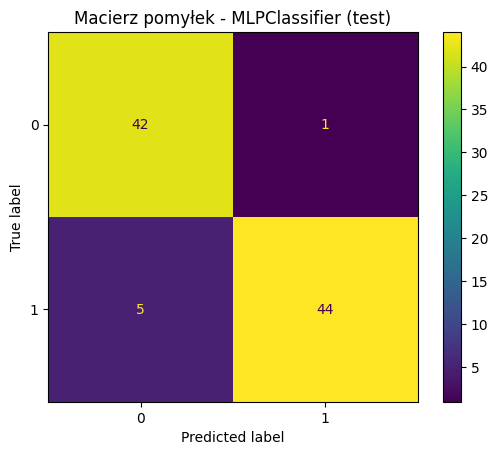


*** Strojenie modelu: ExtraTreesClassifier ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': None, 'clf__max_depth': None}
Średni wynik F1 (CV): 0.9901
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9886685552407932
Precision: 0.9852941176470589
Recall: 0.995049504950495
F1 Score: 0.9901477832512315
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       151
           1       0.99      1.00      0.99       202

    accuracy                           0.99       353
   macro avg       0.99      0.99      0.99       353
weighted avg       0.99      0.99      0.99       353



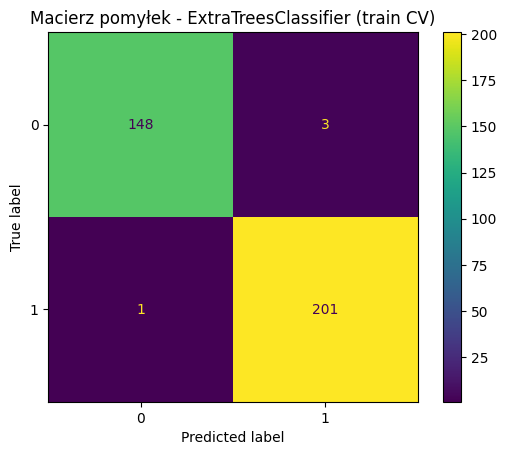

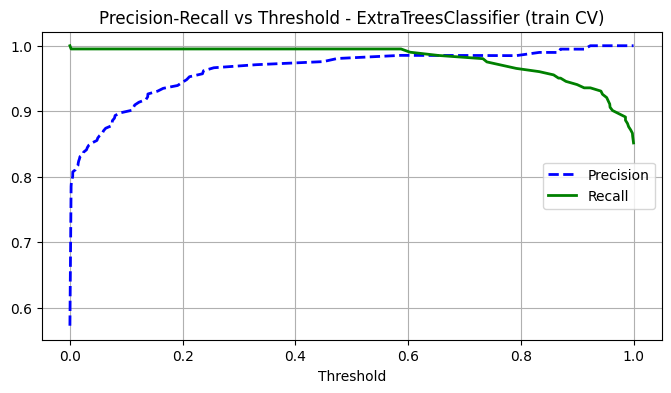

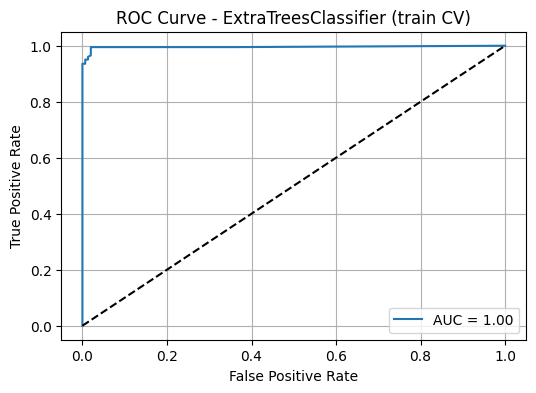

Wyniki na zbiorze testowym dla ExtraTreesClassifier:
Accuracy: 0.9347826086956522
Precision: 1.0
Recall: 0.8775510204081632
F1 Score: 0.9347826086956522
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        43
           1       1.00      0.88      0.93        49

    accuracy                           0.93        92
   macro avg       0.94      0.94      0.93        92
weighted avg       0.94      0.93      0.93        92



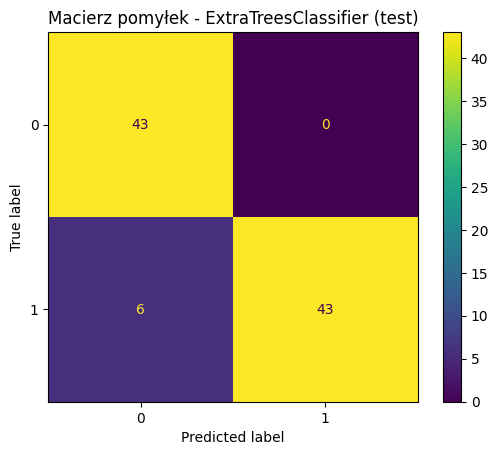


*** Strojenie modelu: BaggingClassifier ***
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Najlepsze parametry: {'clf__n_estimators': 50, 'clf__max_samples': 1.0, 'clf__max_features': 1.0}
Średni wynik F1 (CV): 0.9781
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9745042492917847
Precision: 0.966183574879227
Recall: 0.9900990099009901
F1 Score: 0.9779951100244498
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       151
           1       0.97      0.99      0.98       202

    accuracy                           0.97       353
   macro avg       0.98      0.97      0.97       353
weighted avg       0.97      0.97      0.97       353



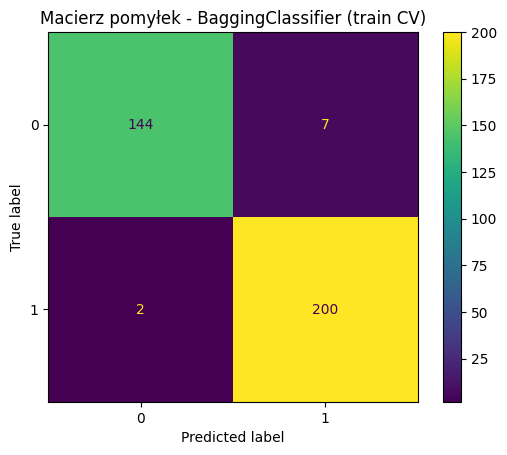

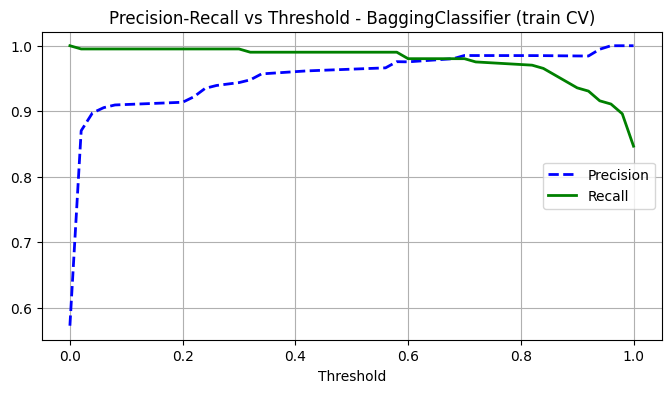

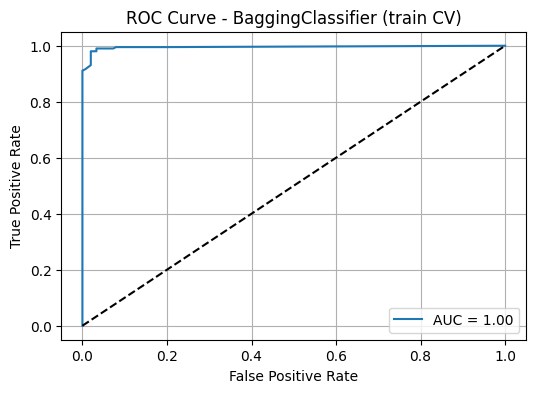

Wyniki na zbiorze testowym dla BaggingClassifier:
Accuracy: 0.9239130434782609
Precision: 1.0
Recall: 0.8571428571428571
F1 Score: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        43
           1       1.00      0.86      0.92        49

    accuracy                           0.92        92
   macro avg       0.93      0.93      0.92        92
weighted avg       0.93      0.92      0.92        92



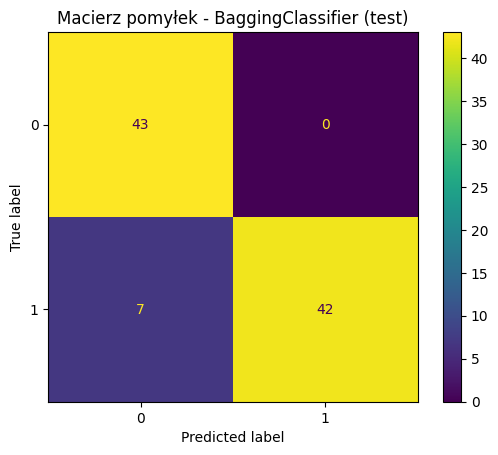


*** Strojenie modelu: HistGradientBoostingClassifier ***
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze parametry: {'clf__min_samples_leaf': 20, 'clf__max_iter': 200, 'clf__max_depth': 10, 'clf__learning_rate': 0.2}
Średni wynik F1 (CV): 0.9852
Metryki na zbiorze treningowym (CV):
Accuracy: 0.9830028328611898
Precision: 0.9803921568627451
Recall: 0.9900990099009901
F1 Score: 0.9852216748768473
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       151
           1       0.98      0.99      0.99       202

    accuracy                           0.98       353
   macro avg       0.98      0.98      0.98       353
weighted avg       0.98      0.98      0.98       353



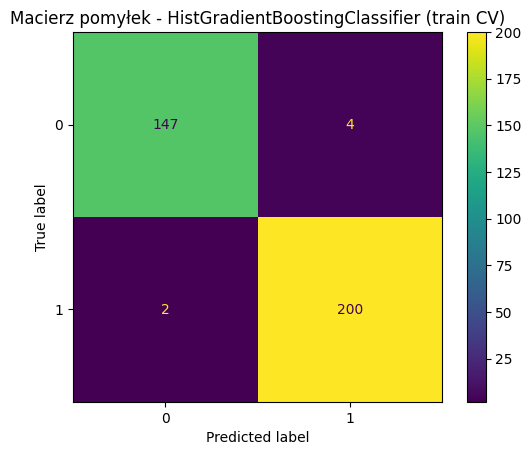

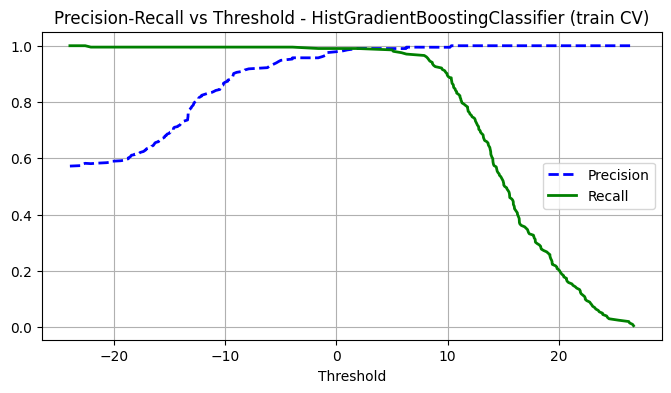

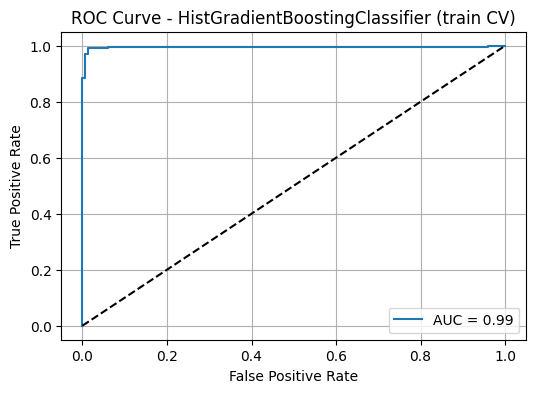

Wyniki na zbiorze testowym dla HistGradientBoostingClassifier:
Accuracy: 0.9347826086956522
Precision: 1.0
Recall: 0.8775510204081632
F1 Score: 0.9347826086956522
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        43
           1       1.00      0.88      0.93        49

    accuracy                           0.93        92
   macro avg       0.94      0.94      0.93        92
weighted avg       0.94      0.93      0.93        92



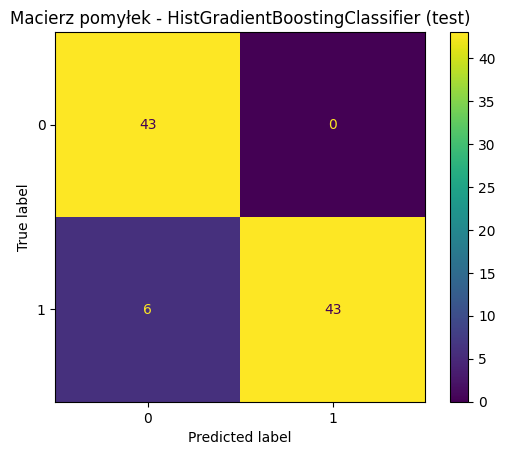

In [ ]:
# Modele
models = {
    "SGDClassifier": SGDClassifier(random_state=42, class_weight='balanced'),
    "RandomForestClassifier": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "SVC RBF": SVC(kernel="rbf", probability=True, random_state=42, class_weight='balanced'),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "MLPClassifier": MLPClassifier(random_state=42, max_iter=1000),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42, class_weight='balanced'),
    "BaggingClassifier": BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(max_iter=100, random_state=42, class_weight='balanced')
}

param_dists = {
    "SGDClassifier": {
        'loss': ['hinge', 'log_loss', 'modified_huber'],
        'alpha': [1e-4, 1e-3, 1e-2],
        'max_iter': [1000, 2000],
        'penalty': ['l2', 'l1', 'elasticnet']
    },
    "RandomForestClassifier": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None , 'sqrt', 'log2']
    },
    "KNeighborsClassifier": {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    "LogisticRegression": {
        'penalty': ['l2', 'elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0, 0.5, 1]
    },
    "SVC RBF": {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    "GradientBoostingClassifier": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 10]
    },
    "AdaBoostClassifier": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    "DecisionTree": {
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "MLPClassifier": {
        'hidden_layer_sizes': [(50,), (100,), (50,50)],
        'activation': ['relu', 'tanh', 'logistic'],
        'solver': ['adam', 'sgd'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate': ['constant', 'adaptive']
    },
    "ExtraTreesClassifier": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None, 'sqrt', 'log2']
    },
    "BaggingClassifier": {
        'n_estimators': [10, 50, 100],
        'max_samples': [0.5, 1.0],
        'max_features': [0.5, 1.0]
    },
    "HistGradientBoostingClassifier": {
        'max_iter': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [20, 50, 100]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

def evaluate_model_full(name, model, X_train, y_train, X_test, y_test):
    print(f"\n*** Strojenie modelu: {name} ***")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

    param_dist = {f"clf__{key}": value for key, value in param_dists[name].items()}

    random_search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=20,
        scoring=scorer,
        cv=cv,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    print(f"Najlepsze parametry: {random_search.best_params_}")
    print(f"Średni wynik F1 (CV): {random_search.best_score_:.4f}")

    best_model = random_search.best_estimator_

    # Predykcje na zbiorze treningowym z CV (do metryk i wykresów)
    if hasattr(best_model.named_steps['clf'], "decision_function"):
        y_scores = cross_val_predict(best_model, X_train, y_train, cv=cv, method="decision_function")
    elif hasattr(best_model.named_steps['clf'], "predict_proba"):
        y_scores = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    else:
        y_scores = None

    y_pred_train = cross_val_predict(best_model, X_train, y_train, cv=cv)

    print("Metryki na zbiorze treningowym (CV):")
    print("Accuracy:", accuracy_score(y_train, y_pred_train))
    print("Precision:", precision_score(y_train, y_pred_train))
    print("Recall:", recall_score(y_train, y_pred_train))
    print("F1 Score:", f1_score(y_train, y_pred_train))
    print(classification_report(y_train, y_pred_train))

    ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
    plt.title(f"Macierz pomyłek - {name} (train CV)")
    plt.show()

    if y_scores is not None:
        precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)
        plt.figure(figsize=(8, 4))
        plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
        plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
        plt.title(f"Precision-Recall vs Threshold - {name} (train CV)")
        plt.xlabel("Threshold")
        plt.legend(loc="center right")
        plt.grid()
        plt.show()

        fpr, tpr, _ = roc_curve(y_train, y_scores)
        auc_value = roc_auc_score(y_train, y_scores)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {auc_value:.2f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name} (train CV)")
        plt.legend()
        plt.grid()
        plt.show()

    # Ewaluacja na zbiorze testowym
    y_test_pred = best_model.predict(X_test)
    print(f"Wyniki na zbiorze testowym dla {name}:")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1 Score:", f1_score(y_test, y_test_pred))
    print(classification_report(y_test, y_test_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
    plt.title(f"Macierz pomyłek - {name} (test)")
    plt.show()

    return best_model

# Trening i ocena wszystkich modeli
trained_models = {}
for name, model in models.items():
    trained_models[name] = evaluate_model_full(name, model, X_train, y_train, X_test, y_test)


### Porównanie wyników modeli po Tuningu hiperparametrów.

| Model                              | Set        | Accuracy | Precision | Recall   | F1 Score |
| ---------------------------------- | ---------- | -------- | --------- | -------- | -------- |
| **SGDClassifier**                  | Train (CV) | 0.957507 | 0.960591  | 0.965347 | 0.962963 |
|                                    | Test       | 0.913043 | 0.976744  | 0.857143 | 0.913043 |
| **RandomForestClassifier**         | Train (CV) | 0.988669 | 0.990099  | 0.990099 | 0.990099 |
|                                    | Test       | 0.923913 | 1.000000  | 0.857143 | 0.923077 |
| **KNeighborsClassifier**           | Train (CV) | 0.971671 | 0.957143  | 0.995050 | 0.975728 |
|                                    | Test       | 0.956522 | 0.959184  | 0.959184 | 0.959184 |
| **LogisticRegression**             | Train (CV) | 0.951841 | 0.974359  | 0.940594 | 0.957179 |
|                                    | Test       | 0.923913 | 1.000000  | 0.857143 | 0.923077 |
| **SVC RBF**                        | Train (CV) | 0.980170 | 0.975610  | 0.990099 | 0.982801 |
|                                    | Test       | 0.956522 | 1.000000  | 0.918367 | 0.957447 |
| **GradientBoostingClassifier**     | Train (CV) | 0.983003 | 0.980392  | 0.990099 | 0.985222 |
|                                    | Test       | 0.913043 | 1.000000  | 0.836735 | 0.911111 |
| **AdaBoostClassifier**             | Train (CV) | 0.974504 | 0.970732  | 0.985149 | 0.977887 |
|                                    | Test       | 0.956522 | 1.000000  | 0.918367 | 0.957447 |
| **DecisionTree**                   | Train (CV) | 0.985836 | 0.985222  | 0.990099 | 0.987654 |
|                                    | Test       | 0.913043 | 1.000000  | 0.836735 | 0.911111 |
| **MLPClassifier**                  | Train (CV) | 0.980170 | 0.971014  | 0.995050 | 0.982885 |
|                                    | Test       | 0.934783 | 0.977778  | 0.897959 | 0.936170 |
| **ExtraTreesClassifier**           | Train (CV) | 0.988669 | 0.985294  | 0.995050 | 0.990148 |
|                                    | Test       | 0.934783 | 1.000000  | 0.877551 | 0.934783 |
| **BaggingClassifier**              | Train (CV) | 0.974504 | 0.966184  | 0.990099 | 0.977995 |
|                                    | Test       | 0.923913 | 1.000000  | 0.857143 | 0.923077 |
| **HistGradientBoostingClassifier** | Train (CV) | 0.983003 | 0.980392  | 0.990099 | 0.985222 |
|                                    | Test       | 0.934783 | 1.000000  | 0.877551 | 0.934783 |


# Analiza wyników modeli

Analizując wyniki przedstawione w tabeli, po tuningu hiperparametrów metodą RandomizedSearch, widzimy wyraźne efekty poprawy jakości modeli i ich generalizacji, choć nadal pojawiają się charakterystyczne różnice między poszczególnymi algorytmami oraz między wynikami na zbiorze treningowym a testowym.

Przede wszystkim większość modeli osiąga bardzo wysoką skuteczność na zbiorze treningowym — często powyżej 95%, co potwierdza, że tuning hiperparametrów dobrze dopasował modele do danych. Jednak istotne jest, jak te wyniki przekładają się na dane testowe, które odzwierciedlają zdolność modeli do generalizacji na nowych, nieznanych danych.

Widać, że modele takie jak **SGDClassifier** oraz **GradientBoostingClassifier** nadal wykazują wyraźny spadek dokładności z treningu na test (odpowiednio z \~95,7% do \~91,3% oraz z \~98,3% do \~91,3%). Pomimo tuningu, mogą one wciąż mieć tendencję do lekkiego przeuczenia, zwłaszcza GradientBoostingClassifier, co może sugerować, że dalsza regularyzacja lub zmiana parametrów modelu mogłaby być korzystna.

Z kolei modele takie jak **KNeighborsClassifier**, **SVC RBF** oraz **AdaBoostClassifier** utrzymują wysoką i stabilną skuteczność zarówno na treningu, jak i na teście (np. KNeighborsClassifier z 97,2% na treningu do 95,7% na teście), co wskazuje, że tuning skutecznie poprawił ich zdolność do generalizacji. Są to jedne z najlepiej zbalansowanych modeli pod względem precyzji i recall, co przekłada się na wysokie wartości F1-score (około 0,95–0,96) zarówno na zbiorze treningowym, jak i testowym.

Analizując precyzję i recall, obserwujemy, że precyzja na zbiorze testowym pozostaje bardzo wysoka — często bliska 1.0, co oznacza, że modele minimalizują liczbę fałszywych alarmów. Jednak recall jest nieco niższy (zazwyczaj w granicach 0.83–0.92), co świadczy o tym, że modele pomijają pewną część prawdziwych pozytywnych przypadków. W praktyce oznacza to, że modele są raczej konserwatywne, preferując unikanie fałszywych alarmów kosztem mniejszej wykrywalności wszystkich przypadków pozytywnych. Przykładowo, **SGDClassifier** ma precyzję testową około 0.98, ale recall na poziomie około 0.86, co pokazuje to właśnie wyważenie.

Warto zwrócić uwagę, że modele zespołowe i oparte na zaawansowanych algorytmach, takie jak **AdaBoostClassifier**, **SVC RBF** oraz **KNeighborsClassifier**, po tuningu wykazują najlepszą generalizację i zachowanie równowagi między precyzją a recall, dzięki czemu uzyskują wysokie wartości F1-score także na zbiorze testowym. W przeciwieństwie do nich, modele takie jak **DecisionTree** czy **SGDClassifier** mają zauważalnie niższe wyniki F1 na testach (około 0.91), co wskazuje na większą podatność na błędy lub nadmierne dopasowanie.

Podsumowując, tuning hiperparametrów metodą RandomizedSearch znacząco poprawił wydajność większości modeli i ich zdolność do generalizacji. Najlepsze wyniki, zarówno pod względem stabilności, jak i balansu precyzji i recall, osiągają modele takie jak KNeighborsClassifier, SVC RBF i AdaBoostClassifier. Natomiast modele wykazujące przeuczenie lub niższą czułość mogą wymagać dodatkowych działań, takich jak zwiększenie regularyzacji, dalsze strojenie parametrów lub modyfikacja danych treningowych.
